In [1]:
# Lightgbm

import os
import warnings
import random

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Paths
data_dir = "/home/parcot1/data/common_window_2001_2010"

train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")


# Columns and settings
target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"

CONTEXT_LENGTHS = [6, 12, 24, 36]
PREDICTION_LENGTH = 1
SEED = 42


# Reproducibility
random.seed(SEED)
np.random.seed(SEED)


# Load data
print("Loading datasets")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# Basic preparation
def basic_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.dropna(subset=[time_col, target_col, id_col]).copy()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df


train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)


# Glacier overlap
train_ids = set(train_df[id_col].unique())
val_ids = set(val_df[id_col].unique())
test_ids = set(test_df[id_col].unique())
common_ids = train_ids & val_ids & test_ids

print("Train glaciers:", len(train_ids))
print("Validation glaciers:", len(val_ids))
print("Test glaciers:", len(test_ids))
print("Common glaciers:", len(common_ids))


# Keep only glaciers present in all splits
train_panel = train_df[train_df[id_col].isin(common_ids)].copy()
val_panel = val_df[val_df[id_col].isin(common_ids)].copy()
test_panel = test_df[test_df[id_col].isin(common_ids)].copy()


# Global minimum date from training data
global_min_date = train_panel[time_col].min()


# Feature engineering
def add_features(df):
    df = df.copy()

    df["year"] = df[time_col].dt.year.astype(np.int32)
    df["month_num"] = df[time_col].dt.month.astype(np.int32)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["time_idx"] = (
        (df[time_col].dt.year - global_min_date.year) * 12
        + (df[time_col].dt.month - global_min_date.month)
    ).astype(np.int32)

    return df


train_panel = add_features(train_panel)
val_panel = add_features(val_panel)
test_panel = add_features(test_panel)


# Identify predictor variables
all_df = pd.concat([train_panel, val_panel, test_panel], ignore_index=True)

exclude_cols = {target_col, id_col, time_col}

feature_cols = [
    col for col in all_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(all_df[col])
]

print("Target variable:", target_col)
print("Series ID:", id_col)
print("Time variable:", time_col)
print("Number of predictors:", len(feature_cols))

print("Predictor variables:")
for i, col in enumerate(feature_cols, start=1):
    print(i, col)


# Missing value check
for name, df in [("Train", train_panel), ("Validation", val_panel), ("Test", test_panel)]:
    missing = df[feature_cols].isna().sum().sum()
    print(name, "missing predictor values:", missing)


# Create training windows
def create_training_windows(data, context_length):
    X = []
    y = []
    metadata = []

    for gid, g in data.groupby(id_col):
        g = g.sort_values(time_col).reset_index(drop=True)

        features = g[feature_cols].to_numpy(dtype=np.float32)
        target = g[target_col].to_numpy(dtype=np.float32)
        dates = g[time_col].to_numpy()

        for i in range(context_length, len(g)):
            context_features = features[i - context_length:i]
            target_value = target[i]

            if np.isnan(target_value):
                continue

            X.append(context_features.reshape(-1))
            y.append(target_value)
            metadata.append({
                id_col: gid,
                time_col: pd.Timestamp(dates[i])
            })

    if len(X) == 0:
        return (
            np.empty((0, context_length * len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            pd.DataFrame(columns=[id_col, time_col])
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# Rolling one-step-ahead forecasting
def rolling_forecast(history_df, future_df, context_length, model):
    predictions = []

    glaciers = sorted(future_df[id_col].dropna().unique())

    for gid in glaciers:
        history_g = history_df[history_df[id_col] == gid].sort_values(time_col).copy()
        future_g = future_df[future_df[id_col] == gid].sort_values(time_col).copy()

        if len(history_g) < context_length:
            continue

        for i in range(len(future_g)):
            current_row = future_g.iloc[i]

            context_df = history_g.sort_values(time_col).tail(context_length).copy()

            if len(context_df) < context_length:
                continue

            X_context = context_df[feature_cols].to_numpy(dtype=np.float32).reshape(1, -1)

            prediction = float(model.predict(X_context)[0])
            actual = float(current_row[target_col])

            predictions.append({
                id_col: gid,
                time_col: current_row[time_col],
                "actual": actual,
                "predicted": prediction
            })

            history_g = pd.concat([history_g, current_row.to_frame().T], ignore_index=True)
            history_g = history_g.sort_values(time_col).reset_index(drop=True)

    return pd.DataFrame(predictions)


# Metrics
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 and np.var(y_true) > 0 else np.nan,
        "N": int(len(y_true))
    }


# Store results
validation_results_all = []
test_results_comparison_all = []
window_counts = []


# Train and evaluate each context
for context_length in CONTEXT_LENGTHS:
    print("\nRunning LightGBM context length =", context_length)

    X_train, y_train, _ = create_training_windows(train_panel, context_length)
    print("Training windows:", len(X_train))

    if len(X_train) == 0:
        print("Skipping context length:", context_length)
        continue

    model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    # Validation
    print("Running rolling validation")

    val_results = rolling_forecast(
        history_df=train_panel,
        future_df=val_panel,
        context_length=context_length,
        model=model
    )

    if not val_results.empty:
        val_metrics = calculate_metrics(val_results["actual"], val_results["predicted"])

        validation_results_all.append({
            "Model": "LightGBM",
            "Split": "Validation",
            "ContextLength": context_length,
            **val_metrics
        })

        print("Validation RMSE:", val_metrics["RMSE"])

    # Comparison-only test
    print("Running comparison-only test")

    train_val_history = (
        pd.concat([train_panel, val_panel], ignore_index=True)
        .sort_values([id_col, time_col])
        .reset_index(drop=True)
    )

    test_results = rolling_forecast(
        history_df=train_val_history,
        future_df=test_panel,
        context_length=context_length,
        model=model
    )

    if not test_results.empty:
        test_metrics = calculate_metrics(test_results["actual"], test_results["predicted"])

        test_results_comparison_all.append({
            "Model": "LightGBM",
            "Split": "Test_Comparison_Only",
            "ContextLength": context_length,
            **test_metrics
        })

        print("Comparison-only test RMSE:", test_metrics["RMSE"])

    window_counts.append({
        "ContextLength": context_length,
        "TrainWindows": len(X_train),
        "ValidationWindows": len(val_results),
        "ValidationGlaciers": val_results[id_col].nunique() if not val_results.empty else 0,
        "TestWindows": len(test_results),
        "TestGlaciers": test_results[id_col].nunique() if not test_results.empty else 0
    })


# Create validation results dataframe
validation_metrics_df = pd.DataFrame(validation_results_all)

# Create comparison-only test dataframe
test_comparison_df = pd.DataFrame(test_results_comparison_all)


# Select best context ONLY using validation RMSE
if not validation_metrics_df.empty:
    best_context = int(
        validation_metrics_df.sort_values("RMSE").iloc[0]["ContextLength"]
    )
else:
    best_context = None

print("\nValidation comparison")
if not validation_metrics_df.empty:
    print(validation_metrics_df[["ContextLength", "RMSE", "MAE", "R2", "N"]])

print("\nBest context based on validation RMSE:", best_context)


# Final official test
final_test_metrics = None

if best_context is not None:
    print("\nRetraining final LightGBM model")
    print("Selected context:", best_context)

    train_val_df = (
        pd.concat([train_panel, val_panel], ignore_index=True)
        .sort_values([id_col, time_col])
        .reset_index(drop=True)
    )

    X_train_final, y_train_final, _ = create_training_windows(train_val_df, best_context)
    print("Final training windows:", len(X_train_final))

    final_model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1
    )

    final_model.fit(X_train_final, y_train_final)

    print("Running official final test")

    final_test_results = rolling_forecast(
        history_df=train_val_df,
        future_df=test_panel,
        context_length=best_context,
        model=final_model
    )

    if not final_test_results.empty:
        final_test_metrics = calculate_metrics(
            final_test_results["actual"],
            final_test_results["predicted"]
        )

        print("\nFinal test results")
        print(
            pd.DataFrame([{
                "Model": "LightGBM",
                "Split": "Final_Test",
                "ContextLength": best_context,
                **final_test_metrics
            }])
        )


print("\nTest comparison results")
if not test_comparison_df.empty:
    print(test_comparison_df[["ContextLength", "RMSE", "MAE", "R2", "N"]])


window_counts_df = pd.DataFrame(window_counts)
print("\nWindow counts")
print(window_counts_df)


print("\nLightGBM experiment complete")
print("Target:", target_col)
print("Series ID:", id_col)
print("Number of predictors:", len(feature_cols))
print("Context lengths:", CONTEXT_LENGTHS)
print("Prediction length:", PREDICTION_LENGTH)
print("Best context:", best_context)

Loading datasets
Train shape: (18984, 25)
Validation shape: (5424, 25)
Test shape: (2706, 25)
Train glaciers: 226
Validation glaciers: 226
Test glaciers: 226
Common glaciers: 226
Target variable: retreat_change_next_month
Series ID: glacier
Time variable: datetime
Number of predictors: 26
Predictor variables:
1 time_idx
2 retreat
3 retreat_change
4 retreat_lag_1
5 retreat_change_lag_1
6 terminus_thermal
7 shelf_thermal
8 undercutting
9 discharge
10 basin_CE
11 basin_CW
12 basin_N
13 basin_NE
14 basin_NW
15 basin_SE
16 basin_SW
17 category_CR
18 category_DW
19 category_FE
20 category_NC
21 category_SC
22 category_SR
23 year
24 month_num
25 month_sin
26 month_cos
Train missing predictor values: 0
Validation missing predictor values: 0
Test missing predictor values: 0

Running LightGBM context length = 6
Training windows: 17628
Running rolling validation
Validation RMSE: 0.12190089508137289
Running comparison-only test
Comparison-only test RMSE: 0.3550882784799016

Running LightGBM contex

In [ ]:
pred_path = os.path.join(output_dir, "lightgbm_final_test_predictions.csv")
final_test_results.to_csv(pred_path, index=False)

In [ ]:
# Chronos
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from chronos import Chronos2Pipeline


DATA_DIR = "/home/parcot1/data/common_window_2001_2010"

TRAIN_FILE = f"{DATA_DIR}/train.csv"
VAL_FILE = f"{DATA_DIR}/validation.csv"
TEST_FILE = f"{DATA_DIR}/test.csv"


ID_COL = "glacier"
TIME_COL = "datetime"
TARGET_COL = "retreat_change_next_month"


CONTEXT_LENGTHS = [6, 12, 24, 36]

PREDICTION_LENGTH = 1

SEED = 42

np.random.seed(SEED)


print("Loading pre-split data")


train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)


print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


required_columns = [
    ID_COL,
    TIME_COL,
    TARGET_COL
]


for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    missing = [
        col for col in required_columns
        if col not in data.columns
    ]

    if missing:
        raise ValueError(
            f"{name} missing columns: {missing}"
        )


def basic_prep(df):

    df = df.copy()

    df[TIME_COL] = pd.to_datetime(
        df[TIME_COL],
        errors="coerce"
    )

    df[TARGET_COL] = pd.to_numeric(
        df[TARGET_COL],
        errors="coerce"
    )

    df[ID_COL] = (
        df[ID_COL]
        .astype(str)
        .str.strip()
    )


    df = df.dropna(
        subset=[
            ID_COL,
            TIME_COL,
            TARGET_COL
        ]
    )


    df = (
        df
        .sort_values(
            [ID_COL, TIME_COL]
        )
        .reset_index(drop=True)
    )

    return df



train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)



all_glaciers = sorted(
    pd.concat(
        [
            train_df[[ID_COL]],
            val_df[[ID_COL]],
            test_df[[ID_COL]]
        ],
        ignore_index=True
    )[ID_COL]
    .astype(str)
    .unique()
)


glacier_codes = {
    glacier: i
    for i, glacier in enumerate(all_glaciers)
}


for df in [
    train_df,
    val_df,
    test_df
]:

    df["glacier_code"] = (
        df[ID_COL]
        .map(glacier_codes)
        .astype(int)
    )



print(
    "Number of glaciers:",
    len(glacier_codes)
)


global_min_date = min(
    train_df[TIME_COL].min(),
    val_df[TIME_COL].min(),
    test_df[TIME_COL].min()
)



def add_datetime_features(df):

    df = df.copy()


    df["year"] = (
        df[TIME_COL]
        .dt.year
        .astype(np.int32)
    )


    df["month_num"] = (
        df[TIME_COL]
        .dt.month
        .astype(np.int32)
    )


    df["month_sin"] = (
        np.sin(
            2*np.pi*
            df["month_num"]/12
        )
        .astype(np.float32)
    )


    df["month_cos"] = (
        np.cos(
            2*np.pi*
            df["month_num"]/12
        )
        .astype(np.float32)
    )


    df["time_idx"] = (
        (
            df[TIME_COL].dt.year
            -
            global_min_date.year
        )
        *
        12
        +
        (
            df[TIME_COL].dt.month
            -
            global_min_date.month
        )
    ).astype(np.int32)


    return df



train_df = add_datetime_features(train_df)
val_df = add_datetime_features(val_df)
test_df = add_datetime_features(test_df)

# PREDICTOR COLUMNS

exclude_columns = {
    ID_COL,
    TIME_COL,
    TARGET_COL
}



all_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)



predictor_columns = [
    col
    for col in all_df.columns
    if (
        col not in exclude_columns
        and
        pd.api.types.is_numeric_dtype(
            all_df[col]
        )
    )
]



print("\nTarget:", TARGET_COL)
print("Series:", ID_COL)

print("\nPredictors:")

for i,col in enumerate(
    predictor_columns,
    start=1
):
    print(i,col)


print(
    "Total predictors:",
    len(predictor_columns)
)



# CLEAN PREDICTORS


for col in predictor_columns:

    train_df[col] = pd.to_numeric(
        train_df[col],
        errors="coerce"
    )

    val_df[col] = pd.to_numeric(
        val_df[col],
        errors="coerce"
    )

    test_df[col] = pd.to_numeric(
        test_df[col],
        errors="coerce"
    )



model_columns = [
    ID_COL,
    TIME_COL,
    TARGET_COL
] + predictor_columns



train_df = train_df.dropna(
    subset=model_columns
)

val_df = val_df.dropna(
    subset=model_columns
)

test_df = test_df.dropna(
    subset=model_columns
)



# LOAD CHRONOS-2

device = (
    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"
)


print(
    "Device:",
    device
)



pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device
)



# FORECAST FUNCTIONS

def create_chronos_input(
        history_df,
        glacier_id,
        prediction_date,
        context_length
):

    glacier_history = (
        history_df[
            history_df[ID_COL] == glacier_id
        ]
        .copy()
    )


    glacier_history = glacier_history[
        glacier_history[TIME_COL]
        <
        prediction_date
    ]


    glacier_history = (
        glacier_history
        .sort_values(TIME_COL)
    )


    if len(glacier_history) < context_length:
        return None


    glacier_history = (
        glacier_history
        .tail(context_length)
    )


    return glacier_history[
        [
            ID_COL,
            TIME_COL,
            TARGET_COL
        ]
        +
        predictor_columns
    ]



def predict_one_step(
        history_df,
        glacier_id,
        prediction_date,
        context_length
):

    input_df = create_chronos_input(
        history_df,
        glacier_id,
        prediction_date,
        context_length
    )


    if input_df is None:
        return None


    with torch.no_grad():

        forecast_df = pipeline.predict_df(
            input_df,
            prediction_length=1,
            quantile_levels=[
                0.1,
                0.5,
                0.9
            ],
            id_column=ID_COL,
            timestamp_column=TIME_COL,
            target=TARGET_COL
        )


    return forecast_df

def extract_prediction(forecast_df):

    possible_columns = [
        "0.5",
        "0.5_prediction",
        "prediction",
        "median"
    ]


    for col in possible_columns:

        if col in forecast_df.columns:

            return float(
                forecast_df[col].iloc[0]
            )


    numeric_columns = [
        col
        for col in forecast_df.select_dtypes(
            include=np.number
        ).columns
        if col not in {
            ID_COL,
            TIME_COL
        }
    ]


    if len(numeric_columns) == 0:

        raise ValueError(
            "Prediction column not found"
        )


    return float(
        forecast_df[
            numeric_columns[0]
        ].iloc[0]
    )



# ROLLING FORECAST


def run_rolling_forecast(
        initial_history,
        forecast_data,
        context_length,
        period_name
):

    print(
        f"{period_name} | Context Length = {context_length}"
    )


    history = initial_history.copy()

    forecast_data = (
        forecast_data
        .sort_values(
            [
                ID_COL,
                TIME_COL
            ]
        )
    )


    results = []


    prediction_dates = sorted(
        forecast_data[TIME_COL]
        .unique()
    )


    for date_index, prediction_date in enumerate(
        prediction_dates,
        start=1
    ):


        prediction_date = pd.Timestamp(
            prediction_date
        )


        print(
            f"{period_name}: "
            f"{date_index}/{len(prediction_dates)} "
            f"{prediction_date.date()}",
            end="\r"
        )


        current_rows = forecast_data[
            forecast_data[TIME_COL]
            ==
            prediction_date
        ]


        for glacier_id in current_rows[ID_COL].unique():


            current_row = current_rows[
                current_rows[ID_COL]
                ==
                glacier_id
            ]


            actual_value = float(
                current_row[TARGET_COL]
                .iloc[0]
            )


            glacier_history = history[
                history[ID_COL]
                ==
                glacier_id
            ]


            glacier_history = glacier_history[
                glacier_history[TIME_COL]
                <
                prediction_date
            ]


            if len(glacier_history) < context_length:
                continue


            try:

                forecast_df = predict_one_step(
                    history,
                    glacier_id,
                    prediction_date,
                    context_length
                )


                if forecast_df is None:
                    continue


                predicted_value = extract_prediction(
                    forecast_df
                )


                results.append(
                    {
                        ID_COL: glacier_id,
                        TIME_COL: prediction_date,
                        "actual": actual_value,
                        "prediction": predicted_value,
                        "context_length": context_length,
                        "period": period_name
                    }
                )


            except Exception as e:

                print(
                    "\nError:",
                    glacier_id,
                    prediction_date,
                    e
                )


        history = pd.concat(
            [
                history,
                current_rows
            ],
            ignore_index=True
        )


        history = (
            history
            .sort_values(
                [
                    ID_COL,
                    TIME_COL
                ]
            )
            .reset_index(drop=True)
        )


    print()

    return pd.DataFrame(results)



# METRICS WITH MSE


def calculate_metrics(predictions_df):

    if predictions_df.empty:

        return {
            "MAE": np.nan,
            "MSE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "N": 0
        }



    y_true = predictions_df["actual"].to_numpy()

    y_pred = predictions_df["prediction"].to_numpy()



    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    mse = mean_squared_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(mse)


    r2 = r2_score(
        y_true,
        y_pred
    )



    return {

        "MAE": float(mae),

        "MSE": float(mse),

        "RMSE": float(rmse),

        "R2": float(r2),

        "N": int(len(y_true))

    }



# VALIDATION EXPERIMENT
validation_results = []


print("\nValidation experiment")


for context_length in CONTEXT_LENGTHS:


    val_predictions = run_rolling_forecast(

        initial_history=train_df,

        forecast_data=val_df,

        context_length=context_length,

        period_name="Validation"

    )



    metrics = calculate_metrics(
        val_predictions
    )



    validation_results.append(

        {

            "Model": "Chronos2",

            "Split": "Validation",

            "ContextLength": context_length,

            "MAE": metrics["MAE"],

            "MSE": metrics["MSE"],

            "RMSE": metrics["RMSE"],

            "R2": metrics["R2"],

            "N": metrics["N"]

        }

    )



validation_results_df = pd.DataFrame(
    validation_results
)


validation_results_df = (
    validation_results_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)



print(
    validation_results_df.to_string(
        index=False
    )
)



# SELECT BEST CONTEXT
best_context = int(
    validation_results_df
    .iloc[0]
    ["ContextLength"]
)


best_validation_rmse = float(
    validation_results_df
    .iloc[0]
    ["RMSE"]
)



print(
    "Best context:",
    best_context
)


print(
    "Best Validation RMSE:",
    best_validation_rmse
)



# TEST EXPERIMENT
train_val_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)


train_val_df = (
    train_val_df
    .sort_values(
        [
            ID_COL,
            TIME_COL
        ]
    )
)



test_results = []



print("\nTest experiment")



for context_length in CONTEXT_LENGTHS:


    test_predictions = run_rolling_forecast(

        initial_history=train_val_df,

        forecast_data=test_df,

        context_length=context_length,

        period_name="Test"

    )


    metrics = calculate_metrics(
        test_predictions
    )



    test_results.append(

        {

            "Model": "Chronos2",

            "Split": "Test",

            "ContextLength": context_length,

            "MAE": metrics["MAE"],

            "MSE": metrics["MSE"],

            "RMSE": metrics["RMSE"],

            "R2": metrics["R2"],

            "N": metrics["N"],

            "SelectedByValidation":
                context_length == best_context

        }

    )



test_results_df = pd.DataFrame(
    test_results
)


print(
    test_results_df.to_string(
        index=False
    )
)



# VALIDATION VS TEST TABLE

validation_summary = validation_results_df[
    [
        "ContextLength",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "N"
    ]
].rename(

    columns={

        "MAE":
        "Validation_MAE",

        "MSE":
        "Validation_MSE",

        "RMSE":
        "Validation_RMSE",

        "R2":
        "Validation_R2",

        "N":
        "Validation_N"

    }

)



test_summary = test_results_df[

    [
        "ContextLength",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "N",
        "SelectedByValidation"
    ]

].rename(

    columns={

        "MAE":
        "Test_MAE",

        "MSE":
        "Test_MSE",

        "RMSE":
        "Test_RMSE",

        "R2":
        "Test_R2",

        "N":
        "Test_N"

    }

)



comparison_df = validation_summary.merge(

    test_summary,

    on="ContextLength"

)



print("\nFinal Validation vs Test")

print(
    comparison_df.to_string(
        index=False
    )
)



# FINAL BEST CONTEXT RESULT
best_test_row = test_results_df[
    test_results_df["ContextLength"]
    ==
    best_context
]



final_results = pd.DataFrame(

[

{

"Model":
"Chronos2",

"Best_Context_Selected_By":
"Validation_RMSE",

"Best_Context":
best_context,

"Best_Validation_RMSE":
best_validation_rmse,

"Best_Context_Test_MAE":
float(best_test_row.iloc[0]["MAE"]),

"Best_Context_Test_MSE":
float(best_test_row.iloc[0]["MSE"]),

"Best_Context_Test_RMSE":
float(best_test_row.iloc[0]["RMSE"]),

"Best_Context_Test_R2":
float(best_test_row.iloc[0]["R2"]),

"Best_Context_Test_N":
int(best_test_row.iloc[0]["N"])

}

]

)



print("\nFINAL RESULTS")

print(
    final_results.to_string(
        index=False
    )
)

In [ ]:
# persistence

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "/home/parcot1/data/common_window_2001_2010"

train_path = os.path.join(DATA_DIR, "train.csv")
val_path= os.path.join(DATA_DIR, "validation.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"
context_lengths = [6, 12, 24, 36]


train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)


required_columns = [id_col, time_col, target_col]
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


def basic_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.dropna(subset=[id_col, time_col, target_col]).copy()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df


train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)

train_ids = set(train_df[id_col].unique())
val_ids = set(val_df[id_col].unique())
test_ids = set(test_df[id_col].unique())
common_ids = train_ids & val_ids & test_ids

print("\nTrain glaciers:", len(train_ids))
print("Validation glaciers:", len(val_ids))
print("Test glaciers:", len(test_ids))
print("Common glaciers:", len(common_ids))

train_panel = train_df[train_df[id_col].isin(common_ids)].copy()
val_panel = val_df[val_df[id_col].isin(common_ids)].copy()
test_panel = test_df[test_df[id_col].isin(common_ids)].copy()

def rolling_persistence_forecast(history_df, future_df, context_length, id_col, time_col, target_col):
    preds = []

    history_groups = {
        gid: g.sort_values(time_col).reset_index(drop=True).copy()
        for gid, g in history_df.groupby(id_col, sort=True)
    }
    future_groups = {
        gid: g.sort_values(time_col).reset_index(drop=True).copy()
        for gid, g in future_df.groupby(id_col, sort=True)
    }

    common_gids = sorted(set(history_groups.keys()) & set(future_groups.keys()))

    for gid in common_gids:
        hist = history_groups[gid]
        fut = future_groups[gid]

        hist_targets = hist[target_col].to_numpy(dtype=np.float32)

        if len(hist_targets) < context_length:
            continue

        for i in range(len(fut)):
            if len(hist_targets) < 1:
                continue

            pred = float(hist_targets[-1])
            actual = float(fut.iloc[i][target_col])

            if np.isnan(pred) or np.isnan(actual):
                continue

            preds.append({
                id_col: str(gid),
                time_col: fut.iloc[i][time_col],
                "actual": actual,
                "predicted": pred
            })

            new_target = np.array([actual], dtype=np.float32)
            hist_targets = np.concatenate([hist_targets, new_target])

    return pd.DataFrame(preds)


def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return {
            "RMSE": np.nan,
            "MSE": np.nan,
            "MAE": np.nan,
            "R2": np.nan,
            "N": 0
        }

    mse = mean_squared_error(y_true, y_pred)

    return {
        "RMSE": float(np.sqrt(mse)),
        "MSE": float(mse),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 and np.var(y_true) > 0 else np.nan,
        "N": int(len(y_true))
    }

validation_results_all = []
test_results_all = []
window_counts = []

for context_length in context_lengths:
    print(f"\nRunning Persistence with context length = {context_length}")

    val_results = rolling_persistence_forecast(
        history_df=train_panel,
        future_df=val_panel,
        context_length=context_length,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col
    )

    if not val_results.empty:
        val_metrics = calculate_metrics(val_results["actual"], val_results["predicted"])
        validation_results_all.append({
            "Model": "Persistence",
            "Split": "Validation",
            "ContextLength": context_length,
            **val_metrics
        })
        print("Validation metrics:", val_metrics)

    train_val_history = (
        pd.concat([train_panel, val_panel], ignore_index=True)
        .sort_values([id_col, time_col])
        .reset_index(drop=True)
    )

    test_results = rolling_persistence_forecast(
        history_df=train_val_history,
        future_df=test_panel,
        context_length=context_length,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col
    )

    if not test_results.empty:
        test_metrics = calculate_metrics(test_results["actual"], test_results["predicted"])
        test_results_all.append({
            "Model": "Persistence",
            "Split": "Test_Comparison_Only",
            "ContextLength": context_length,
            **test_metrics
        })
        print("Test comparison metrics:", test_metrics)

    window_counts.append({
        "ContextLength": context_length,
        "ValidationWindows": len(val_results),
        "ValidationGlaciers": val_results[id_col].nunique() if not val_results.empty else 0,
        "TestWindows": len(test_results),
        "TestGlaciers": test_results[id_col].nunique() if not test_results.empty else 0
    })


validation_metrics_df = pd.DataFrame(validation_results_all)
test_metrics_df = pd.DataFrame(test_results_all)
window_counts_df = pd.DataFrame(window_counts)

if not validation_metrics_df.empty:
    validation_metrics_df = validation_metrics_df.sort_values("RMSE").reset_index(drop=True)
    best_context = int(validation_metrics_df.iloc[0]["ContextLength"])
else:
    best_context = None

print("\nValidation comparison")
if not validation_metrics_df.empty:
    print(validation_metrics_df[["ContextLength", "RMSE", "MSE", "MAE", "R2", "N"]])

print("\nBest context based on validation RMSE:", best_context)

print("\nTest comparison results")
if not test_metrics_df.empty:
    test_metrics_df = test_metrics_df.sort_values("ContextLength").reset_index(drop=True)
    print(test_metrics_df[["ContextLength", "RMSE", "MSE", "MAE", "R2", "N"]])

print("\nWindow counts")
print(window_counts_df)


final_test_df = None

if best_context is not None:
    train_val_df = (
        pd.concat([train_panel, val_panel], ignore_index=True)
        .sort_values([id_col, time_col])
        .reset_index(drop=True)
    )

    final_test_results = rolling_persistence_forecast(
        history_df=train_val_df,
        future_df=test_panel,
        context_length=best_context,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col
    )

    if not final_test_results.empty:
        final_test_metrics = calculate_metrics(
            final_test_results["actual"],
            final_test_results["predicted"]
        )

        final_test_df = pd.DataFrame([{
            "Model": "Persistence",
            "Split": "Official_Final_Test",
            "ContextLength": best_context,
            **final_test_metrics
        }])

        print("\nOfficial final test results")
        print(final_test_df[["ContextLength", "RMSE", "MSE", "MAE", "R2", "N"]])


print("\nPersistence experiment complete")
print("Target:", target_col)
print("Series ID:", id_col)
print("Context lengths:", context_lengths)
print("Best context:", best_context)

Loading datasets...
Train: (18984, 25) Validation: (5424, 25) Test: (2706, 25)
Train rows: 18984 glaciers: 226 start: 2001-01-01 00:00:00 end: 2007-12-01 00:00:00
Validation rows: 5424 glaciers: 226 start: 2008-01-01 00:00:00 end: 2009-12-01 00:00:00
Test rows: 2706 glaciers: 226 start: 2010-01-01 00:00:00 end: 2010-12-01 00:00:00
Train glaciers: 226 Val glaciers: 226 Test glaciers: 226 Common glaciers: 226
Number of glacier codes: 226
Target: retreat_change_next_month | Series ID: glacier | Time index: datetime
Predictors: ['time_idx', 'retreat', 'retreat_change', 'retreat_lag_1', 'retreat_change_lag_1', 'terminus_thermal', 'shelf_thermal', 'undercutting', 'discharge', 'basin_CE', 'basin_CW', 'basin_N', 'basin_NE', 'basin_NW', 'basin_SE', 'basin_SW', 'category_CR', 'category_DW', 'category_FE', 'category_NC', 'category_SC', 'category_SR', 'glacier_code', 'year', 'month_num', 'month_sin', 'month_cos']
Number of predictors: 27
Train missing predictor values: 0
Validation missing predict

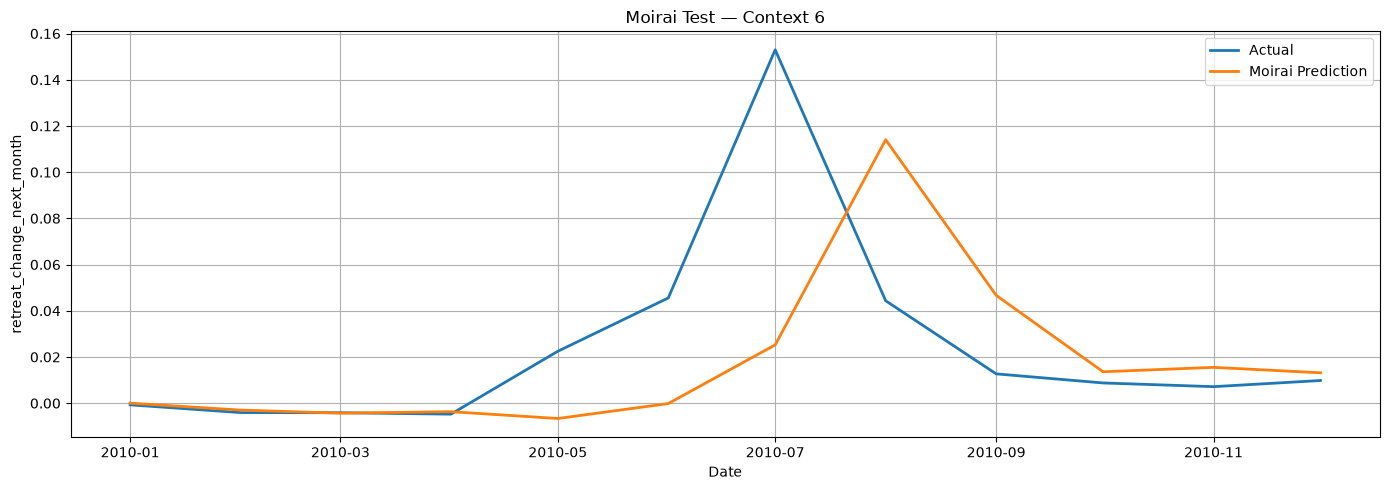

Context 6 completed.

Running Moirai — context length = 12
Running rolling validation...
Running rolling test...


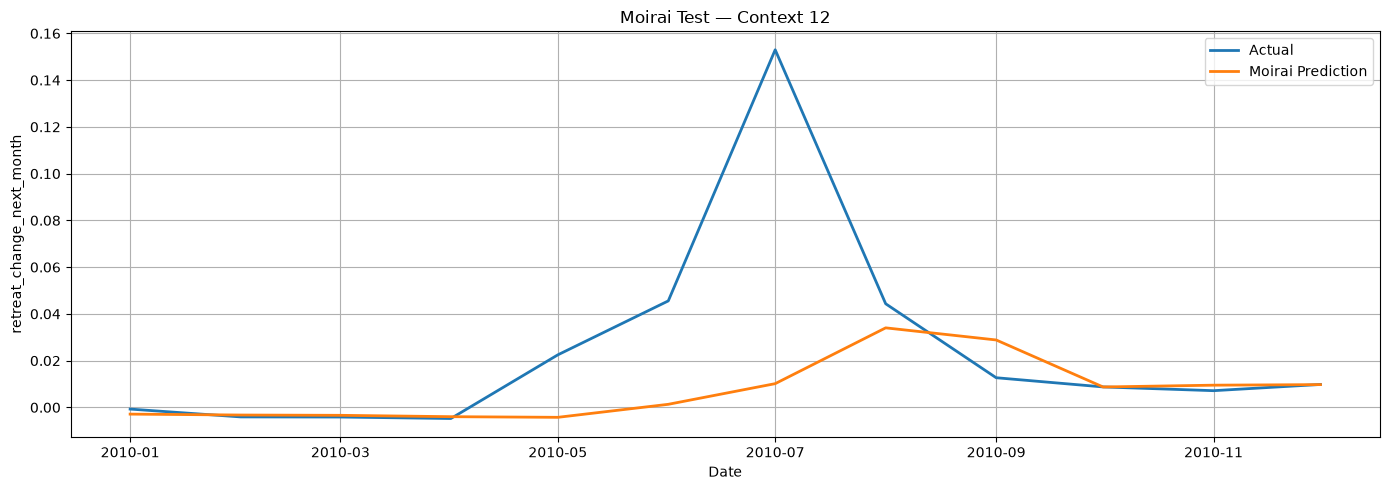

Context 12 completed.

Running Moirai — context length = 24
Running rolling validation...
Running rolling test...


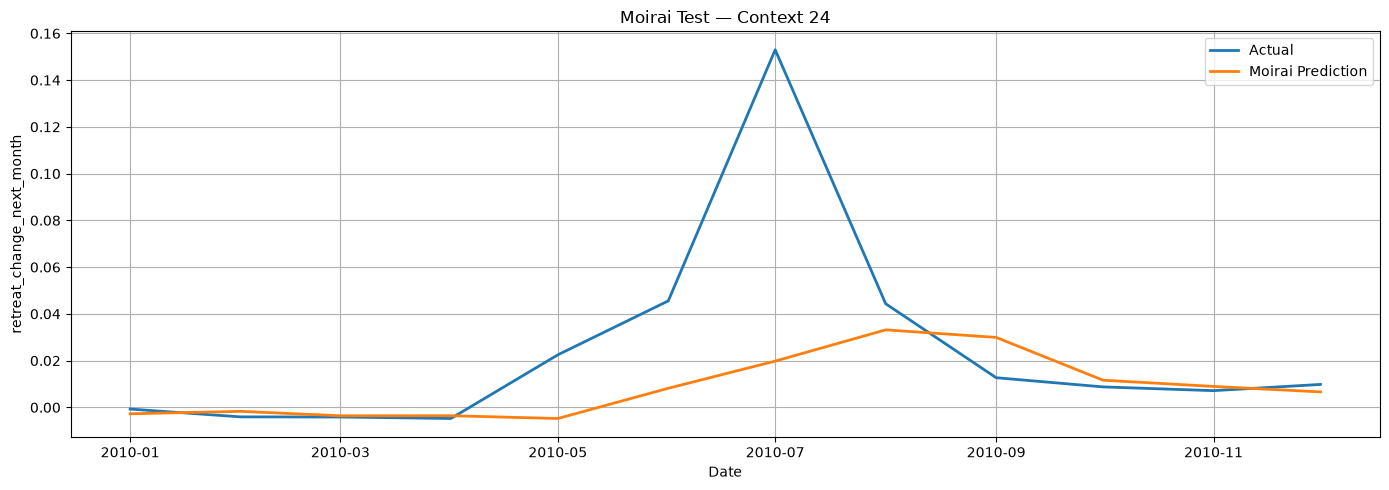

Context 24 completed.

Running Moirai — context length = 36
Running rolling validation...
Running rolling test...


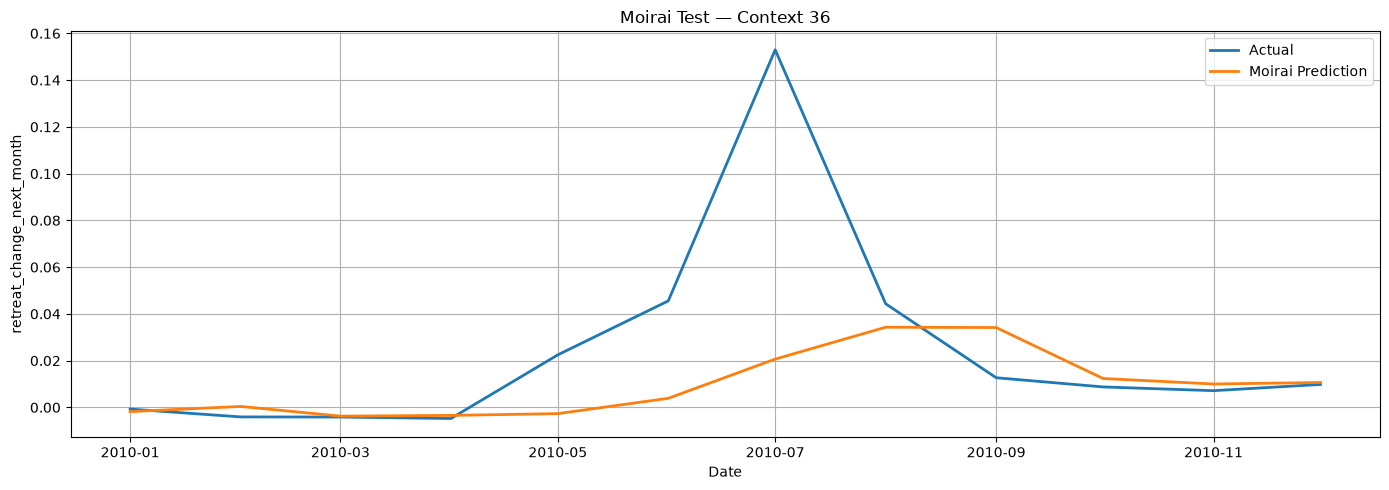

Context 36 completed.
Best validation context: 36
Final test performance using best validation context:
    Model Split  ContextLength       MAE       MSE      RMSE        R2     N
3  Moirai  Test             36  0.040224  0.128865  0.358977 -0.015576  2706

Moirai model results
    Model       Split  ContextLength       MAE       MSE      RMSE        R2  \
0  Moirai        Test              6  0.047514  0.192288  0.438507 -0.515412   
1  Moirai        Test             12  0.040650  0.128878  0.358996 -0.015684   
2  Moirai        Test             24  0.040069  0.128970  0.359124 -0.016407   
3  Moirai        Test             36  0.040224  0.128865  0.358977 -0.015576   
4  Moirai  Validation              6  0.044304  0.019171  0.138460 -0.090967   
5  Moirai  Validation             12  0.040243  0.017359  0.131753  0.012171   
6  Moirai  Validation             24  0.038271  0.015452  0.124307  0.120663   
7  Moirai  Validation             36  0.038379  0.014374  0.119892  0.182023   


In [1]:
# Moirai
import os
import warnings
import random

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from gluonts.dataset.common import ListDataset
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# Paths
data_dir = "/home/parcot1/data/common_window_2001_2010"
train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")

# Settings
target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"
CONTEXT_LENGTHS = [6, 12, 24, 36]
PREDICTION_LENGTH = 1
NUM_SAMPLES = 100
BATCH_SIZE = 16
MODEL_NAME = "Salesforce/moirai-1.1-R-small"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Load data
print("Loading datasets...")
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape, "Validation:", val_df.shape, "Test:", test_df.shape)

# Basic prep
def basic_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, target_col, id_col]).copy()
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df

train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)

# Dataset diagnostics
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(name, "rows:", len(df), "glaciers:", df[id_col].nunique(),
          "start:", df[time_col].min(), "end:", df[time_col].max())

# Glacier overlap
train_ids = set(train_df[id_col].unique())
val_ids = set(val_df[id_col].unique())
test_ids = set(test_df[id_col].unique())
common_ids = train_ids & val_ids & test_ids

print("Train glaciers:", len(train_ids), "Val glaciers:", len(val_ids),
      "Test glaciers:", len(test_ids), "Common glaciers:", len(common_ids))

# Keep glaciers present in all splits
train_df = train_df[train_df[id_col].isin(common_ids)].copy()
val_df = val_df[val_df[id_col].isin(common_ids)].copy()
test_df = test_df[test_df[id_col].isin(common_ids)].copy()

# Glacier encoding (built from training glaciers)
train_glaciers = sorted(train_df[id_col].dropna().unique())
glacier_codes = {g: i for i, g in enumerate(train_glaciers)}
print("Number of glacier codes:", len(glacier_codes))

# Global start date for time index
global_min_date = train_df[time_col].min()

# Add glacier and datetime features
def add_features(df):
    df = df.copy()
    df["glacier_code"] = df[id_col].map(glacier_codes)

    if df["glacier_code"].isna().any():
        unknown = df.loc[df["glacier_code"].isna(), id_col].unique()
        raise ValueError(f"Unknown glacier IDs found: {unknown}")

    df["glacier_code"] = df["glacier_code"].astype(np.int32)
    df["year"] = df[time_col].dt.year.astype(np.int32)
    df["month_num"] = df[time_col].dt.month.astype(np.int32)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["time_idx"] = (
        (df[time_col].dt.year - global_min_date.year) * 12
        + (df[time_col].dt.month - global_min_date.month)
    ).astype(np.int32)
    return df

train_df = add_features(train_df)
val_df = add_features(val_df)
test_df = add_features(test_df)

# Predictor columns
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
exclude_cols = {target_col, id_col, time_col}
predictor_cols = [
    col for col in all_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(all_df[col])
]

print("Target:", target_col, "| Series ID:", id_col, "| Time index:", time_col)
print("Predictors:", predictor_cols)
print("Number of predictors:", len(predictor_cols))

if target_col in predictor_cols:
    raise ValueError("Target variable was accidentally included in predictor columns.")

# Missing value check
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    missing = df[predictor_cols].isna().sum().sum()
    print(name, "missing predictor values:", missing)

# Detect frequency
all_dates = pd.concat([train_df[time_col], val_df[time_col], test_df[time_col]]).drop_duplicates().sort_values()
month_start_count = all_dates.dt.is_month_start.sum()
month_end_count = all_dates.dt.is_month_end.sum()

FREQ = "M" if month_start_count >= month_end_count else "M"
print("Detected frequency:", FREQ)

# Metrics
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
        "N": int(len(y_true)),
    }

# Build one-step forecast dataset for a given prediction date
def create_dataset_for_date(data, prediction_date, context_length):
    entries = []
    actual_rows = []

    for glacier_id, g in data.groupby(id_col):
        g = g.sort_values(time_col).reset_index(drop=True)
        history = g[g[time_col] < prediction_date].copy()
        future = g[g[time_col] == prediction_date].copy()

        if future.empty or len(history) < context_length:
            continue

        history = history.iloc[-context_length:].copy()

        if history[target_col].isna().any():
            continue
        if history[predictor_cols].isna().any().any():
            continue

        target_values = history[target_col].astype(np.float32).values
        past_features = history[predictor_cols].astype(np.float32).to_numpy().T

        entries.append({
            "item_id": str(glacier_id),
            "start": pd.Period(history[time_col].iloc[0], freq=FREQ),
            "target": target_values,
            "past_feat_dynamic_real": past_features,
        })

        actual_rows.append({
            id_col: str(glacier_id),
            time_col: prediction_date,
            "actual": float(future[target_col].iloc[0]),
        })

    if len(entries) == 0:
        return None, pd.DataFrame()

    dataset = ListDataset(entries, freq=FREQ)
    return dataset, pd.DataFrame(actual_rows)

# Rolling one-step forecast across all prediction dates
def run_predictions(data, prediction_dates, context_length, predictor, split_name):
    all_results = []

    for prediction_date in prediction_dates:
        dataset, actual_df = create_dataset_for_date(data, prediction_date, context_length)

        if dataset is None or actual_df.empty:
            continue

        forecasts = list(predictor.predict(dataset))
        rows = []

        for forecast in forecasts:
            glacier_id = str(forecast.item_id)
            matching_actual = actual_df[actual_df[id_col].astype(str) == glacier_id]

            if matching_actual.empty:
                continue

            actual_value = float(matching_actual["actual"].iloc[0])
            predicted_value = float(np.median(forecast.samples[:, 0]))

            rows.append({
                id_col: glacier_id,
                time_col: prediction_date,
                "actual": actual_value,
                "predicted": predicted_value,
                "Split": split_name,
                "ContextLength": context_length,
            })

        if rows:
            all_results.append(pd.DataFrame(rows))

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results, ignore_index=True)
    return result.sort_values([id_col, time_col]).reset_index(drop=True)

# Prediction dates
validation_dates = sorted(val_df[time_col].drop_duplicates().tolist())
test_dates = sorted(test_df[time_col].drop_duplicates().tolist())
print("Validation months:", len(validation_dates), "| Test months:", len(test_dates))

# Load Moirai
print("Loading Moirai model...")
module = MoiraiModule.from_pretrained(MODEL_NAME)
print("Moirai loaded.")

# Rolling histories (only rows before prediction date are used inside create_dataset_for_date)
train_val_history = pd.concat([train_df, val_df], ignore_index=True).sort_values([id_col, time_col]).reset_index(drop=True)
full_history = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values([id_col, time_col]).reset_index(drop=True)

# Storage
all_metrics = []
all_predictions = []
window_counts = []

# Run Moirai for each context length
for ctx in CONTEXT_LENGTHS:
    print(f"\nRunning Moirai — context length = {ctx}")

    model = MoiraiForecast(
        module=module,
        prediction_length=PREDICTION_LENGTH,
        context_length=ctx,
        patch_size="auto",
        num_samples=NUM_SAMPLES,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=len(predictor_cols),
    )

    predictor = model.create_predictor(batch_size=BATCH_SIZE)

    print("Running rolling validation...")
    val_results = run_predictions(train_val_history, validation_dates, ctx, predictor, "Validation")

    print("Running rolling test...")
    test_results = run_predictions(full_history, test_dates, ctx, predictor, "Test")

    window_counts.append({
        "ContextLength": ctx,
        "ValidationPredictions": len(val_results),
        "ValidationGlaciers": val_results[id_col].nunique() if not val_results.empty else 0,
        "TestPredictions": len(test_results),
        "TestGlaciers": test_results[id_col].nunique() if not test_results.empty else 0,
    })

    if not val_results.empty:
        val_metrics = calculate_metrics(val_results["actual"].values, val_results["predicted"].values)
        all_metrics.append({"Model": "Moirai", "Split": "Validation", "ContextLength": ctx, **val_metrics})
        all_predictions.append(val_results)

    if not test_results.empty:
        test_metrics = calculate_metrics(test_results["actual"].values, test_results["predicted"].values)
        all_metrics.append({"Model": "Moirai", "Split": "Test", "ContextLength": ctx, **test_metrics})
        all_predictions.append(test_results)

        # Plot average actual vs prediction by month (display only, not saved)
        plot_df = (
            test_results.groupby(time_col, as_index=False)[["actual", "predicted"]]
            .mean()
            .sort_values(time_col)
        )

        plt.figure(figsize=(14, 5))
        plt.plot(plot_df[time_col], plot_df["actual"], label="Actual", linewidth=2)
        plt.plot(plot_df[time_col], plot_df["predicted"], label="Moirai Prediction", linewidth=2)
        plt.title(f"Moirai Test — Context {ctx}")
        plt.xlabel("Date")
        plt.ylabel(target_col)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()

    print(f"Context {ctx} completed.")

# Final results
if len(all_metrics) == 0:
    raise ValueError("No predictions were generated. Check data coverage, missing values, context lengths, and Moirai configuration.")

metrics_df = pd.DataFrame(all_metrics).sort_values(["Split", "ContextLength"]).reset_index(drop=True)
predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
window_counts_df = pd.DataFrame(window_counts)

# Select best context
validation_metrics = metrics_df[metrics_df["Split"] == "Validation"].copy()
best_context = None

if not validation_metrics.empty:
    best_context = int(validation_metrics.sort_values("RMSE").iloc[0]["ContextLength"])
    print("Best validation context:", best_context)

    best_test = metrics_df[(metrics_df["Split"] == "Test") & (metrics_df["ContextLength"] == best_context)]
    print("Final test performance using best validation context:")
    print(best_test)

# Final output
print("\nMoirai model results")
print(metrics_df)

print("\nWindow counts")
print(window_counts_df)

print("\nExperiment complete")
print("Target:", target_col)
print("Series ID:", id_col)
print("Time index:", time_col)
print("Number of predictors:", len(predictor_cols))
print("Predictors:", predictor_cols)
print("Context lengths:", CONTEXT_LENGTHS)
print("Prediction length:", PREDICTION_LENGTH)
print("Detected frequency:", FREQ)
print("Best context:", best_context) 

In [2]:
# TFT
# TFT_GLUONTS

# Imports and setup
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.tft import TemporalFusionTransformerEstimator

# Paths and config
data_dir = "/home/parcot1/data/common_window_2001_2010"
train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")

target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"
series_id_col = "glacier_code"

freq = "M"
CONTEXT_LENGTHS = [6, 12, 24, 36]
PREDICTION_LENGTH = 1

BATCH_SIZE = 16
NUM_BATCHES_PER_EPOCH = 50
EPOCHS = 50
LEARNING_RATE = 1e-5
SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Metric calculation function
def calc_metrics(model_name, split_name, context_length, y_true, y_pred, evaluation_type):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "model": model_name,
        "split": split_name,
        "evaluation_type": evaluation_type,
        "context_length": context_length,
        "RMSE": float(np.sqrt(mse)),
        "MSE": float(mse),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 and np.var(y_true) > 0 else np.nan,
        "n_obs": int(len(y_true))
    }

# Data preparation functions
def minimal_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df.dropna(subset=[time_col, target_col]).copy()
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df

def add_datetime_features(df, global_min_date):
    df = df.copy()
    df["year"] = df[time_col].dt.year.astype(np.int32)
    df["month_num"] = df[time_col].dt.month.astype(np.int32)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0).astype(np.float32)
    df["time_idx"] = (
        (df[time_col].dt.year - global_min_date.year) * 12
        + (df[time_col].dt.month - global_min_date.month)
    ).astype(np.int32)
    df["time_idx_scaled"] = (df["time_idx"] / 12.0).astype(np.float32)
    return df

# Feature matrix builders
def build_past_dynamic_matrix(g, cols):
    if len(cols) == 0:
        return None
    mats = []
    for c in cols:
        vals = pd.to_numeric(g[c], errors="coerce").to_numpy(dtype=np.float32)
        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        mats.append(vals)
    return np.vstack(mats).astype(np.float32)

def build_known_dynamic_matrix(g):
    return np.vstack([
        g["month_sin"].to_numpy(dtype=np.float32),
        g["month_cos"].to_numpy(dtype=np.float32),
        g["month_num"].to_numpy(dtype=np.float32),
        g["year"].to_numpy(dtype=np.float32),
        g["time_idx_scaled"].to_numpy(dtype=np.float32)
    ]).astype(np.float32)

# Dataset construction functions
def make_train_dataset(data, context_length, past_covariate_cols):
    entries = []
    for gid, g in data.groupby(series_id_col):
        g = g.sort_values(time_col).reset_index(drop=True)
        if len(g) < (context_length + PREDICTION_LENGTH):
            continue
        if g[target_col].isna().any():
            continue

        target = g[target_col].to_numpy(dtype=np.float32)
        past_features = build_past_dynamic_matrix(g, past_covariate_cols)
        known_features = build_known_dynamic_matrix(g)

        if past_features is None:
            continue
        if past_features.shape[1] != len(target):
            continue
        if known_features.shape[1] != len(target):
            continue

        entry = {
            "start": pd.Period(g[time_col].iloc[0], freq=freq),
            "target": target,
            "item_id": str(gid),
            "feat_static_cat": np.array([int(gid)], dtype=np.int64),
            "feat_dynamic_real": known_features,
            "past_feat_dynamic_real": past_features
        }
        entries.append(entry)

    return ListDataset(entries, freq=freq)

def make_one_step_entry(history_g, future_row, context_length, past_covariate_cols):
    hist = history_g.sort_values(time_col).tail(context_length).copy()
    if len(hist) != context_length:
        return None

    target = hist[target_col].to_numpy(dtype=np.float32)
    past_features = build_past_dynamic_matrix(hist, past_covariate_cols)
    if past_features is None:
        return None

    hist_known = build_known_dynamic_matrix(hist)
    future_known = np.array([
        [np.float32(future_row["month_sin"])],
        [np.float32(future_row["month_cos"])],
        [np.float32(future_row["month_num"])],
        [np.float32(future_row["year"])],
        [np.float32(future_row["time_idx_scaled"])]
    ], dtype=np.float32)

    known_features = np.concatenate([hist_known, future_known], axis=1)

    return {
        "start": pd.Period(hist[time_col].iloc[0], freq=freq),
        "target": target,
        "item_id": str(hist[series_id_col].iloc[0]),
        "feat_static_cat": np.array([int(hist[series_id_col].iloc[0])], dtype=np.int64),
        "feat_dynamic_real": known_features,
        "past_feat_dynamic_real": past_features
    }

# Rolling forecast function
def rolling_forecast(history_df, future_df, context_length, past_covariate_cols, predictor, split_name):
    results = []
    glaciers = sorted(future_df[series_id_col].dropna().unique())

    for gid in glaciers:
        history_g = history_df[history_df[series_id_col] == gid].sort_values(time_col).copy()
        future_g = future_df[future_df[series_id_col] == gid].sort_values(time_col).copy()

        if len(history_g) < context_length or len(future_g) == 0:
            continue

        for i in range(len(future_g)):
            current_row = future_g.iloc[i]
            context_df = history_g.sort_values(time_col).tail(context_length).copy()
            if len(context_df) < context_length:
                continue

            entry = make_one_step_entry(
                history_g=context_df,
                future_row=current_row,
                context_length=context_length,
                past_covariate_cols=past_covariate_cols
            )
            if entry is None:
                continue

            try:
                rolling_ds = ListDataset([entry], freq=freq)
                forecast = next(predictor.predict(rolling_ds))
                pred = float(forecast.quantile(0.5)[0])

                results.append({
                    "glacier_code": int(gid),
                    "glacier": current_row[id_col] if id_col in current_row.index else None,
                    "datetime": current_row[time_col],
                    "actual": float(current_row[target_col]),
                    "predicted": pred,
                    "split": split_name,
                    "context_length": context_length
                })

                history_g = pd.concat([history_g, current_row.to_frame().T], ignore_index=True)
                history_g = history_g.sort_values(time_col).reset_index(drop=True)

            except Exception as e:
                print(f"Skipped glacier_code={gid} at {current_row[time_col]}: {e}")

    return pd.DataFrame(results)

# Load and prepare data
print("Loading data")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

train_df = minimal_prep(train_df)
val_df = minimal_prep(val_df)
test_df = minimal_prep(test_df)

all_glaciers = sorted(
    pd.concat([train_df[[id_col]], val_df[[id_col]], test_df[[id_col]]], ignore_index=True)[id_col]
    .dropna()
    .astype(str)
    .unique()
)
glacier_code_map = {g: i for i, g in enumerate(all_glaciers)}

train_df[series_id_col] = train_df[id_col].map(glacier_code_map).astype(int)
val_df[series_id_col] = val_df[id_col].map(glacier_code_map).astype(int)
test_df[series_id_col] = test_df[id_col].map(glacier_code_map).astype(int)

global_min_date = min(
    train_df[time_col].min(),
    val_df[time_col].min(),
    test_df[time_col].min()
)

train_df = add_datetime_features(train_df, global_min_date)
val_df = add_datetime_features(val_df, global_min_date)
test_df = add_datetime_features(test_df, global_min_date)

print("Train:", len(train_df), "rows |", train_df[series_id_col].nunique(), "glaciers")
print("Validation:", len(val_df), "rows |", val_df[series_id_col].nunique(), "glaciers")
print("Test:", len(test_df), "rows |", test_df[series_id_col].nunique(), "glaciers")

# Variable selection
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

exclude_cols = {
    target_col, id_col, series_id_col, time_col,
    "year", "month_num", "month_sin", "month_cos",
    "time_idx", "time_idx_scaled"
}

past_covariate_cols = [
    c for c in all_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(all_df[c])
]

print("Target:", target_col)
print("Series ID:", series_id_col)
print("Past covariates:", len(past_covariate_cols))
for c in past_covariate_cols:
    print(" -", c)

print("Known time features: month_sin, month_cos, month_num, year, time_idx_scaled")

# Stage 1: context selection
all_metrics = []
all_predictions = []
window_counts = []

print("Stage 1: context selection")

for ctx in CONTEXT_LENGTHS:
    print("Context:", ctx)

    train_ds = make_train_dataset(train_df, ctx, past_covariate_cols)
    train_entries = list(train_ds)

    if len(train_entries) == 0:
        print("Skipped: no valid training series")
        continue

    print("Training series:", len(train_entries))

    val_history = train_df.copy()
    test_history = (
        pd.concat([train_df, val_df], ignore_index=True)
        .sort_values([series_id_col, time_col])
        .reset_index(drop=True)
    )

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    estimator = TemporalFusionTransformerEstimator(
        freq=freq,
        prediction_length=PREDICTION_LENGTH,
        context_length=ctx,
        hidden_dim=32,
        variable_dim=16,
        num_heads=4,
        dropout_rate=0.1,
        batch_size=BATCH_SIZE,
        num_batches_per_epoch=NUM_BATCHES_PER_EPOCH,
        lr=LEARNING_RATE,
        quantiles=[0.1, 0.5, 0.9],
        static_cardinalities=[len(glacier_code_map)],
        dynamic_dims=[1, 1, 1, 1, 1],
        past_dynamic_dims=[1] * len(past_covariate_cols) if len(past_covariate_cols) > 0 else [],
        trainer_kwargs={
            "max_epochs": EPOCHS,
            "accelerator": accelerator,
            "devices": 1,
            "enable_progress_bar": False,
            "logger": False
        }
    )

    print("Training")
    predictor = estimator.train(training_data=train_ds)

    print("Validation")
    val_results = rolling_forecast(
        history_df=val_history,
        future_df=val_df,
        context_length=ctx,
        past_covariate_cols=past_covariate_cols,
        predictor=predictor,
        split_name="validation"
    )

    print("Test")
    test_results = rolling_forecast(
        history_df=test_history,
        future_df=test_df,
        context_length=ctx,
        past_covariate_cols=past_covariate_cols,
        predictor=predictor,
        split_name="test_all_contexts"
    )

    window_counts.append({
        "context_length": ctx,
        "train_series": len(train_entries),
        "validation_windows": len(val_results),
        "validation_glaciers": val_results["glacier_code"].nunique() if not val_results.empty else 0,
        "test_windows": len(test_results),
        "test_glaciers": test_results["glacier_code"].nunique() if not test_results.empty else 0
    })

    if not val_results.empty:
        all_metrics.append(
            calc_metrics("TFT_GluonTS", "validation", ctx, val_results["actual"], val_results["predicted"], "context_selection")
        )
        all_predictions.append(val_results)

    if not test_results.empty:
        all_metrics.append(
            calc_metrics("TFT_GluonTS", "test_all_contexts", ctx, test_results["actual"], test_results["predicted"], "comparison_only")
        )
        all_predictions.append(test_results)

# Select best context
metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True) if len(all_predictions) > 0 else pd.DataFrame()
window_counts_df = pd.DataFrame(window_counts)

validation_metrics = (
    metrics_df[metrics_df["split"] == "validation"]
    .sort_values("RMSE")
    .reset_index(drop=True)
)

if not validation_metrics.empty:
    best_ctx = int(validation_metrics.iloc[0]["context_length"])
    best_val_rmse = float(validation_metrics.iloc[0]["RMSE"])
else:
    best_ctx = None
    best_val_rmse = None

print("Validation results")
print(validation_metrics)
print("Best context:", best_ctx)
print("Best validation RMSE:", best_val_rmse)

# Stage 2: final model training
final_test_results = pd.DataFrame()

if best_ctx is not None:
    print("Stage 2: final model")
    print("Best context:", best_ctx)

    train_val_df = (
        pd.concat([train_df, val_df], ignore_index=True)
        .sort_values([series_id_col, time_col])
        .reset_index(drop=True)
    )

    final_train_ds = make_train_dataset(train_val_df, best_ctx, past_covariate_cols)
    final_train_entries = list(final_train_ds)
    print("Final training series:", len(final_train_entries))

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    final_estimator = TemporalFusionTransformerEstimator(
        freq=freq,
        prediction_length=PREDICTION_LENGTH,
        context_length=best_ctx,
        hidden_dim=32,
        variable_dim=16,
        num_heads=4,
        dropout_rate=0.1,
        batch_size=BATCH_SIZE,
        num_batches_per_epoch=NUM_BATCHES_PER_EPOCH,
        lr=LEARNING_RATE,
        quantiles=[0.1, 0.5, 0.9],
        static_cardinalities=[len(glacier_code_map)],
        dynamic_dims=[1, 1, 1, 1, 1],
        past_dynamic_dims=[1] * len(past_covariate_cols) if len(past_covariate_cols) > 0 else [],
        trainer_kwargs={
            "max_epochs": EPOCHS,
            "accelerator": accelerator,
            "devices": 1,
            "enable_progress_bar": False,
            "logger": False
        }
    )

    print("Training final model")
    final_predictor = final_estimator.train(training_data=final_train_ds)

    print("Running final test")
    final_test_results = rolling_forecast(
        history_df=train_val_df,
        future_df=test_df,
        context_length=best_ctx,
        past_covariate_cols=past_covariate_cols,
        predictor=final_predictor,
        split_name="test_final_best_context"
    )

# Final metrics
if not final_test_results.empty:
    final_test_metric = calc_metrics(
        model_name="TFT_GluonTS",
        split_name="test_final_best_context",
        context_length=best_ctx,
        y_true=final_test_results["actual"],
        y_pred=final_test_results["predicted"],
        evaluation_type="official_final_test"
    )
    metrics_df = pd.concat([metrics_df, pd.DataFrame([final_test_metric])], ignore_index=True)
    predictions_df = pd.concat([predictions_df, final_test_results], ignore_index=True)

metrics_df = metrics_df.sort_values(["split", "context_length"]).reset_index(drop=True)

# Print results
print("All results")
print(metrics_df.to_string(index=False))

print("Validation comparison")
val_compare = metrics_df[metrics_df["split"] == "validation"]
if not val_compare.empty:
    print(val_compare[["context_length", "RMSE", "MAE", "R2", "n_obs"]].sort_values("RMSE").to_string(index=False))

print("Test comparison")
test_compare = metrics_df[metrics_df["split"] == "test_all_contexts"]
if not test_compare.empty:
    print(test_compare[["context_length", "RMSE", "MAE", "R2", "n_obs"]].sort_values("context_length").to_string(index=False))
else:
    print("No test comparison results")

print("Final test")
official_test = metrics_df[metrics_df["split"] == "test_final_best_context"]
if not official_test.empty:
    print(official_test[["context_length", "RMSE", "MAE", "MSE", "R2", "n_obs"]].to_string(index=False))
else:
    print("Final test results were not generated")

print("Window counts")
print(window_counts_df.to_string(index=False))

# Summary
print("Done")
print("Target:", target_col)
print("Series ID:", series_id_col)
print("Number of past covariates:", len(past_covariate_cols))
print("Context lengths tested:", CONTEXT_LENGTHS)
print("Prediction length:", PREDICTION_LENGTH)
print("Best context:", best_ctx)
print("Best validation RMSE:", best_val_rmse)

PyTorch version: 2.4.1+cu121
CUDA available: True
GPU: Quadro RTX 6000
Loading data
Train: 18984 rows | 226 glaciers
Validation: 5424 rows | 226 glaciers
Test: 2706 rows | 226 glaciers
Target: retreat_change_next_month
Series ID: glacier_code
Past covariates: 21
 - retreat
 - retreat_change
 - retreat_lag_1
 - retreat_change_lag_1
 - terminus_thermal
 - shelf_thermal
 - undercutting
 - discharge
 - basin_CE
 - basin_CW
 - basin_N
 - basin_NE
 - basin_NW
 - basin_SE
 - basin_SW
 - category_CR
 - category_DW
 - category_FE
 - category_NC
 - category_SC
 - category_SR
Known time features: month_sin, month_cos, month_num, year, time_idx_scaled
Stage 1: context selection
Context: 6


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                           | Params | In sizes                                                                      | Out sizes
-----------------------------------------------------------------------------------------------------------------------------------------------------
0 | model | TemporalFusionTransformerModel | 109 K  | [[1, 6], [1, 6], [1, 1], [1, 1], [1, 7, 6], [1, 7, 0], [1, 6, 21], [1, 6, 0]] | [1, 3, 1]
-----------------------------------------------------------------------------------------------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.440     Total estimated model params size (MB)


Training series: 226
Training


Epoch 0, global step 50: 'train_loss' reached 0.12528 (best 0.12528), saving model to '/home/parcot1/data/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' was not in top 1
Epoch 2, global step 150: 'train_loss' was not in top 1
Epoch 3, global step 200: 'train_loss' reached 0.10835 (best 0.10835), saving model to '/home/parcot1/data/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' was not in top 1
Epoch 5, global step 300: 'train_loss' was not in top 1
Epoch 6, global step 350: 'train_loss' was not in top 1
Epoch 7, global step 400: 'train_loss' was not in top 1
Epoch 8, global step 450: 'train_loss' reached 0.09949 (best 0.09949), saving model to '/home/parcot1/data/checkpoints/epoch=8-step=450.ckpt' as top 1
Epoch 9, global step 500: 'train_loss' was not in top 1
Epoch 10, global step 550: 'train_loss' was not in top 1
Epoch 11, global step 600: 'train_loss' reached 0.09338 (best 0.09338), saving model to '/home/parco

Validation
Test
Context: 12


...

Validation
Test
Validation results
         model       split    evaluation_type  context_length      RMSE  \
0  TFT_GluonTS  validation  context_selection              36  0.135016   
1  TFT_GluonTS  validation  context_selection              12  0.135110   
2  TFT_GluonTS  validation  context_selection              24  0.135838   
3  TFT_GluonTS  validation  context_selection               6  0.149416   

        MSE       MAE        R2  n_obs  
0  0.018229  0.049655 -0.037371   5424  
1  0.018255  0.049965 -0.038808   5424  
2  0.018452  0.050153 -0.050033   5424  
3  0.022325  0.054753 -0.270444   5424  
Best context: 36
Best validation RMSE: 0.13501604351093954
Stage 2: final model
Best context: 36


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                           | Params | In sizes                                                                            | Out sizes
-----------------------------------------------------------------------------------------------------------------------------------------------------------
0 | model | TemporalFusionTransformerModel | 109 K  | [[1, 36], [1, 36], [1, 1], [1, 1], [1, 37, 6], [1, 37, 0], [1, 36, 21], [1, 36, 0]] | [1, 3, 1]
-----------------------------------------------------------------------------------------------------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.440     Total estimated model params size (MB)


Final training series: 226
Training final model


Epoch 0, global step 50: 'train_loss' reached 0.10671 (best 0.10671), saving model to '/home/parcot1/data/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 0.10385 (best 0.10385), saving model to '/home/parcot1/data/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' was not in top 1
Epoch 3, global step 200: 'train_loss' was not in top 1
Epoch 4, global step 250: 'train_loss' reached 0.09483 (best 0.09483), saving model to '/home/parcot1/data/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, global step 300: 'train_loss' reached 0.08889 (best 0.08889), saving model to '/home/parcot1/data/checkpoints/epoch=5-step=300.ckpt' as top 1
Epoch 6, global step 350: 'train_loss' was not in top 1
Epoch 7, global step 400: 'train_loss' was not in top 1
Epoch 8, global step 450: 'train_loss' was not in top 1
Epoch 9, global step 500: 'train_loss' reached 0.07851 (best 0.07851), saving model to '/home/parcot1/data/checkpoints

Running final test
All results
      model                   split     evaluation_type  context_length     RMSE      MSE      MAE        R2  n_obs
TFT_GluonTS       test_all_contexts     comparison_only               6 0.367631 0.135153 0.050468 -0.065132   2706
TFT_GluonTS       test_all_contexts     comparison_only              12 0.358743 0.128697 0.047550 -0.014251   2706
TFT_GluonTS       test_all_contexts     comparison_only              24 0.358867 0.128785 0.047901 -0.014951   2706
TFT_GluonTS       test_all_contexts     comparison_only              36 0.356827 0.127326 0.047830 -0.003447   2706
TFT_GluonTS test_final_best_context official_final_test              36 0.357530 0.127828 0.047399 -0.007402   2706
TFT_GluonTS              validation   context_selection               6 0.149416 0.022325 0.054753 -0.270444   5424
TFT_GluonTS              validation   context_selection              12 0.135110 0.018255 0.049965 -0.038808   5424
TFT_GluonTS              validation   con

In [3]:
# FINAL MODEL TRAINING FOR ALL CONTEXT LENGTHS
final_test_results_all = []
final_metrics_all = []

print("\n" + "=" * 90)
print("STAGE 2: FINAL TEST EVALUATION FOR ALL CONTEXT LENGTHS")
print("=" * 90)

# Train + Validation
train_val_df = (
    pd.concat([train_df, val_df], ignore_index=True)
    .sort_values([series_id_col, time_col])
    .reset_index(drop=True)
)

for ctx in CONTEXT_LENGTHS:

    print("\n" + "=" * 90)
    print(f"FINAL MODEL — CONTEXT LENGTH: {ctx}")
    print("=" * 90)

    # Build final training dataset using TRAIN + VALIDATION
    final_train_ds = make_train_dataset(
        train_val_df,
        ctx,
        past_covariate_cols
    )

    final_train_entries = list(final_train_ds)

    if len(final_train_entries) == 0:
        print(f"No valid training series for context {ctx}. Skipping.")
        continue

    print("Final training series:", len(final_train_entries))

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    # Create TFT model
    final_estimator = TemporalFusionTransformerEstimator(
        freq=freq,
        prediction_length=PREDICTION_LENGTH,
        context_length=ctx,

        hidden_dim=32,
        variable_dim=16,
        num_heads=4,
        dropout_rate=0.1,

        batch_size=BATCH_SIZE,
        num_batches_per_epoch=NUM_BATCHES_PER_EPOCH,
        lr=LEARNING_RATE,

        quantiles=[0.1, 0.5, 0.9],

        static_cardinalities=[len(glacier_code_map)],

        dynamic_dims=[1, 1, 1, 1, 1],

        past_dynamic_dims=(
            [1] * len(past_covariate_cols)
            if len(past_covariate_cols) > 0
            else []
        ),

        trainer_kwargs={
            "max_epochs": EPOCHS,
            "accelerator": accelerator,
            "devices": 1,
            "enable_progress_bar": False,
            "logger": False
        }
    )

    # Train final model
    print(f"Training final TFT model for context {ctx}...")

    final_predictor = final_estimator.train(
        training_data=final_train_ds
    )

    # Final TEST
    print(f"Running final TEST for context {ctx}...")

    ctx_test_results = rolling_forecast(
        history_df=train_val_df,
        future_df=test_df,
        context_length=ctx,
        past_covariate_cols=past_covariate_cols,
        predictor=final_predictor,
        split_name="test_final"
    )

    if ctx_test_results.empty:
        print(f"No test predictions generated for context {ctx}.")
        continue

    # Add to predictions
    final_test_results_all.append(ctx_test_results)

    # Calculate official final metrics
    ctx_metric = calc_metrics(
        model_name="TFT_GluonTS",
        split_name="test_final",
        context_length=ctx,
        y_true=ctx_test_results["actual"],
        y_pred=ctx_test_results["predicted"],
        evaluation_type="official_final_test"
    )

    final_metrics_all.append(ctx_metric)

    print("\nFinal Test Results")
    print("-" * 60)
    print(f"Context : {ctx}")
    print(f"RMSE    : {ctx_metric['RMSE']:.6f}")
    print(f"MSE     : {ctx_metric['MSE']:.6f}")
    print(f"MAE     : {ctx_metric['MAE']:.6f}")
    print(f"R2      : {ctx_metric['R2']:.6f}")
    print(f"N       : {ctx_metric['n_obs']}")

# COMBINE FINAL RESULTS
final_test_metrics_df = pd.DataFrame(final_metrics_all)

if len(final_test_results_all) > 0:
    final_test_predictions_df = pd.concat(
        final_test_results_all,
        ignore_index=True
    )
else:
    final_test_predictions_df = pd.DataFrame()

# FINAL RESULTS TABLE
print("\n" + "=" * 100)
print("OFFICIAL FINAL TEST RESULTS — ALL CONTEXT LENGTHS")
print("=" * 100)

if not final_test_metrics_df.empty:

    final_test_metrics_df = (
        final_test_metrics_df
        .sort_values("context_length")
        .reset_index(drop=True)
    )

    print(
        final_test_metrics_df[
            [
                "context_length",
                "RMSE",
                "MSE",
                "MAE",
                "R2",
                "n_obs"
            ]
        ].to_string(index=False)
    )

else:
    print("No final test results were generated.")

# SAVE RESULTS
results_dir = os.path.join(data_dir, "TFT_final_results")
os.makedirs(results_dir, exist_ok=True)

if not final_test_metrics_df.empty:

    metrics_path = os.path.join(
        results_dir,
        "TFT_GluonTS_OFFICIAL_FINAL_TEST_ALL_CONTEXTS.csv"
    )

    final_test_metrics_df.to_csv(
        metrics_path,
        index=False
    )

    print("\nSaved final metrics:")
    print(metrics_path)

if not final_test_predictions_df.empty:

    predictions_path = os.path.join(
        results_dir,
        "TFT_GluonTS_OFFICIAL_FINAL_TEST_PREDICTIONS_ALL_CONTEXTS.csv"
    )

    final_test_predictions_df.to_csv(
        predictions_path,
        index=False
    )

    print("\nSaved final predictions:")
    print(predictions_path)

print("\n" + "=" * 100)
print("FINAL TEST EVALUATION COMPLETE")
print("=" * 100)


STAGE 2: FINAL TEST EVALUATION FOR ALL CONTEXT LENGTHS

FINAL MODEL — CONTEXT LENGTH: 6


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                           | Params | In sizes                                                                      | Out sizes
-----------------------------------------------------------------------------------------------------------------------------------------------------
0 | model | TemporalFusionTransformerModel | 109 K  | [[1, 6], [1, 6], [1, 1], [1, 1], [1, 7, 6], [1, 7, 0], [1, 6, 21], [1, 6, 0]] | [1, 3, 1]
-----------------------------------------------------------------------------------------------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.440     Total estimated model params size (MB)


Final training series: 226
Training final TFT model for context 6...


Epoch 0, global step 50: 'train_loss' reached 0.13947 (best 0.13947), saving model to '/home/parcot1/data/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 0.11143 (best 0.11143), saving model to '/home/parcot1/data/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' was not in top 1
Epoch 3, global step 200: 'train_loss' reached 0.11114 (best 0.11114), saving model to '/home/parcot1/data/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' was not in top 1
Epoch 5, global step 300: 'train_loss' reached 0.11094 (best 0.11094), saving model to '/home/parcot1/data/checkpoints/epoch=5-step=300.ckpt' as top 1
Epoch 6, global step 350: 'train_loss' reached 0.10664 (best 0.10664), saving model to '/home/parcot1/data/checkpoints/epoch=6-step=350.ckpt' as top 1
Epoch 7, global step 400: 'train_loss' reached 0.08122 (best 0.08122), saving model to '/home/parcot1/data/checkpoints/epoch=7-step=400

Running final TEST for context 6...

Final Test Results
------------------------------------------------------------
Context : 6
RMSE    : 0.361836
MSE     : 0.130926
MAE     : 0.046339
R2      : -0.031817
N       : 2706

FINAL MODEL — CONTEXT LENGTH: 12


...

Running final TEST for context 24...

Final Test Results
------------------------------------------------------------
Context : 24
RMSE    : 0.358161
MSE     : 0.128279
MAE     : 0.047091
R2      : -0.010962
N       : 2706

FINAL MODEL — CONTEXT LENGTH: 36


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type                           | Params | In sizes                                                                            | Out sizes
-----------------------------------------------------------------------------------------------------------------------------------------------------------
0 | model | TemporalFusionTransformerModel | 109 K  | [[1, 36], [1, 36], [1, 1], [1, 1], [1, 37, 6], [1, 37, 0], [1, 36, 21], [1, 36, 0]] | [1, 3, 1]
-----------------------------------------------------------------------------------------------------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.440     Total estimated model params size (MB)


Final training series: 226
Training final TFT model for context 36...


Epoch 0, global step 50: 'train_loss' reached 0.10123 (best 0.10123), saving model to '/home/parcot1/data/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' was not in top 1
Epoch 2, global step 150: 'train_loss' was not in top 1
Epoch 3, global step 200: 'train_loss' was not in top 1
Epoch 4, global step 250: 'train_loss' reached 0.09963 (best 0.09963), saving model to '/home/parcot1/data/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, global step 300: 'train_loss' reached 0.09098 (best 0.09098), saving model to '/home/parcot1/data/checkpoints/epoch=5-step=300.ckpt' as top 1
Epoch 6, global step 350: 'train_loss' reached 0.08149 (best 0.08149), saving model to '/home/parcot1/data/checkpoints/epoch=6-step=350.ckpt' as top 1
Epoch 7, global step 400: 'train_loss' was not in top 1
Epoch 8, global step 450: 'train_loss' was not in top 1
Epoch 9, global step 500: 'train_loss' was not in top 1
Epoch 10, global step 550: 'train_loss' was not in top 1
Epoch

Running final TEST for context 36...

Final Test Results
------------------------------------------------------------
Context : 36
RMSE    : 0.357473
MSE     : 0.127787
MAE     : 0.046981
R2      : -0.007079
N       : 2706

OFFICIAL FINAL TEST RESULTS — ALL CONTEXT LENGTHS
 context_length     RMSE      MSE      MAE        R2  n_obs
              6 0.361836 0.130926 0.046339 -0.031817   2706
             12 0.360969 0.130298 0.047689 -0.026873   2706
             24 0.358161 0.128279 0.047091 -0.010962   2706
             36 0.357473 0.127787 0.046981 -0.007079   2706

Saved final metrics:
/home/parcot1/data/common_window_2001_2010/TFT_final_results/TFT_GluonTS_OFFICIAL_FINAL_TEST_ALL_CONTEXTS.csv

Saved final predictions:
/home/parcot1/data/common_window_2001_2010/TFT_final_results/TFT_GluonTS_OFFICIAL_FINAL_TEST_PREDICTIONS_ALL_CONTEXTS.csv

FINAL TEST EVALUATION COMPLETE


In [ ]:
# liner reg
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Configuration
data_dir = "/home/parcot1/data/common_window_2001_2010"

train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")

target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"

context_lengths = [6, 12, 24, 36]


# Load data
print("Loading pre-split data")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# Basic preprocessing
def basic_prep(df):
    df = df.copy()

    df[time_col] = pd.to_datetime(
        df[time_col],
        errors="coerce"
    )

    df[id_col] = (
        df[id_col]
        .astype(str)
        .str.strip()
    )

    df = df.dropna(
        subset=[
            time_col,
            target_col,
            id_col
        ]
    ).copy()

    df = (
        df
        .sort_values(
            [id_col, time_col]
        )
        .reset_index(drop=True)
    )

    return df


train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)


print("\nAfter preprocessing:")
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# Feature engineering
def add_engineered_features(df):
    df = df.copy()

    df["year"] = (
        df[time_col]
        .dt.year
        .astype(int)
    )

    df["month_num"] = (
        df[time_col]
        .dt.month
        .astype(int)
    )

    df["month_sin"] = np.sin(
        2 * np.pi * df["month_num"] / 12.0
    )

    df["month_cos"] = np.cos(
        2 * np.pi * df["month_num"] / 12.0
    )

    return df


train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)


# Select predictor variables
excluded_columns = [
    target_col,
    id_col,
    time_col
]

feature_cols = [
    col
    for col in train_df.columns
    if (
        col not in excluded_columns
        and pd.api.types.is_numeric_dtype(
            train_df[col]
        )
    )
]


print("\nFeature information")
print("Target variable:", target_col)
print("Series ID:", id_col)
print("Time variable:", time_col)
print("Number of predictors:", len(feature_cols))

print("\nPredictors used:")

for i, col in enumerate(
    feature_cols,
    start=1
):
    print(f"{i}. {col}")


# Ensure numeric predictor values
for col in feature_cols:

    train_df[col] = pd.to_numeric(
        train_df[col],
        errors="coerce"
    )

    val_df[col] = pd.to_numeric(
        val_df[col],
        errors="coerce"
    )

    test_df[col] = pd.to_numeric(
        test_df[col],
        errors="coerce"
    )


# Missing-value imputation
# Training medians only
train_medians = (
    train_df[feature_cols]
    .median()
)


def fill_missing_values(df):

    df = df.copy()

    df[feature_cols] = (
        df[feature_cols]
        .fillna(train_medians)
    )

    return df


train_df = fill_missing_values(
    train_df
)

val_df = fill_missing_values(
    val_df
)

test_df = fill_missing_values(
    test_df
)


# Feature scaling
# Fit on training data only
feature_scaler = StandardScaler()

feature_scaler.fit(
    train_df[feature_cols]
)


def scale_features(df):

    df = df.copy()

    df[feature_cols] = (
        feature_scaler.transform(
            df[feature_cols]
        )
    )

    return df


train_scaled = scale_features(
    train_df
)

val_scaled = scale_features(
    val_df
)

test_scaled = scale_features(
    test_df
)


# Create training windows
def create_training_windows(
    df,
    context
):

    X = []
    y = []
    metadata = []

    for glacier_id, g in df.groupby(
        id_col,
        sort=False
    ):

        g = (
            g
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        features = (
            g[feature_cols]
            .values
            .astype(np.float32)
        )

        targets = (
            g[target_col]
            .values
            .astype(np.float32)
        )

        dates = g[time_col].values

        for i in range(
            context,
            len(g)
        ):

            X_window = (
                features[
                    i - context:i
                ]
                .reshape(-1)
            )

            target_value = targets[i]

            if np.isnan(target_value):
                continue

            if np.isnan(X_window).any():
                continue

            X.append(X_window)

            y.append(target_value)

            metadata.append({
                id_col: glacier_id,
                time_col: pd.Timestamp(
                    dates[i]
                )
            })

    if len(X) == 0:

        return (
            np.empty(
                (
                    0,
                    context * len(feature_cols)
                ),
                dtype=np.float32
            ),
            np.empty(
                (0,),
                dtype=np.float32
            ),
            pd.DataFrame(
                columns=[
                    id_col,
                    time_col
                ]
            )
        )

    return (
        np.asarray(
            X,
            dtype=np.float32
        ),
        np.asarray(
            y,
            dtype=np.float32
        ),
        pd.DataFrame(metadata)
    )


# Create rolling forecast windows
def create_rolling_forecast_windows(
    history_df,
    forecast_df,
    context
):

    X = []
    y = []
    metadata = []

    forecast_glaciers = (
        forecast_df[id_col]
        .unique()
    )

    for glacier_id in forecast_glaciers:

        history_g = (
            history_df[
                history_df[id_col]
                == glacier_id
            ]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        forecast_g = (
            forecast_df[
                forecast_df[id_col]
                == glacier_id
            ]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        if len(forecast_g) == 0:
            continue

        history_features = (
            history_g[feature_cols]
            .values
            .astype(np.float32)
        )

        forecast_features = (
            forecast_g[feature_cols]
            .values
            .astype(np.float32)
        )

        forecast_targets = (
            forecast_g[target_col]
            .values
            .astype(np.float32)
        )

        for j in range(
            len(forecast_g)
        ):

            available_history = np.vstack(
                [
                    history_features,
                    forecast_features[:j]
                ]
            )

            if len(
                available_history
            ) < context:

                continue

            X_window = (
                available_history[
                    -context:
                ]
                .reshape(-1)
            )

            target_value = (
                forecast_targets[j]
            )

            if np.isnan(target_value):
                continue

            if np.isnan(X_window).any():
                continue

            X.append(X_window)

            y.append(target_value)

            metadata.append({
                id_col: glacier_id,
                time_col: forecast_g.loc[
                    j,
                    time_col
                ]
            })

    if len(X) == 0:

        return (
            np.empty(
                (
                    0,
                    context * len(feature_cols)
                ),
                dtype=np.float32
            ),
            np.empty(
                (0,),
                dtype=np.float32
            ),
            pd.DataFrame(
                columns=[
                    id_col,
                    time_col
                ]
            )
        )

    return (
        np.asarray(
            X,
            dtype=np.float32
        ),
        np.asarray(
            y,
            dtype=np.float32
        ),
        pd.DataFrame(metadata)
    )


# Metrics
def calculate_metrics(
    y_true,
    y_pred
):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "N": len(y_true)
    }


# Validation
print(
    "\n"
    + "=" * 70
)

print("VALIDATION")

print(
    "=" * 70
)

validation_results = []

for context in context_lengths:

    print(
        f"\nValidation context = {context}"
    )

    X_train, y_train, _ = (
        create_training_windows(
            train_scaled,
            context
        )
    )

    X_val, y_val, meta_val = (
        create_rolling_forecast_windows(
            history_df=train_scaled,
            forecast_df=val_scaled,
            context=context
        )
    )

    print(
        "Training windows:",
        len(X_train)
    )

    print(
        "Validation windows:",
        len(X_val)
    )

    if (
        len(X_train) == 0
        or len(X_val) == 0
    ):

        print(
            "Skipping context:",
            context
        )

        continue

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    val_pred = model.predict(
        X_val
    )

    val_metrics = calculate_metrics(
        y_val,
        val_pred
    )

    validation_results.append({

        "Model":
            "Multiple Linear Regression",

        "ContextLength":
            context,

        "ValidationMAE":
            val_metrics["MAE"],

        "ValidationMSE":
            val_metrics["MSE"],

        "ValidationRMSE":
            val_metrics["RMSE"],

        "ValidationR2":
            val_metrics["R2"],

        "ValidationN":
            val_metrics["N"]
    })


# Validation results
validation_results_df = pd.DataFrame(
    validation_results
)

if validation_results_df.empty:

    raise ValueError(
        "No valid validation results were produced."
    )


validation_results_df = (
    validation_results_df
    .sort_values(
        "ValidationRMSE"
    )
    .reset_index(drop=True)
)


print(
    "\n"
    + "=" * 70
)

print("VALIDATION RESULTS")

print(
    "=" * 70
)

print(
    validation_results_df.to_string(
        index=False
    )
)


# Select best context using validation RMSE only
best_context = int(
    validation_results_df.iloc[0][
        "ContextLength"
    ]
)

best_validation_rmse = (
    validation_results_df.iloc[0][
        "ValidationRMSE"
    ]
)


print(
    "\nBest context selected using validation RMSE:",
    best_context
)

print(
    "Best validation RMSE:",
    best_validation_rmse
)


# Combine train + validation
train_val_scaled = (
    pd.concat(
        [
            train_scaled,
            val_scaled
        ],
        ignore_index=True
    )
    .sort_values(
        [
            id_col,
            time_col
        ]
    )
    .reset_index(drop=True)
)


# Test evaluation
print(
    "\n"
    + "=" * 70
)

print("TEST EVALUATION")

print(
    "=" * 70
)

test_results = []

for context in context_lengths:

    print(
        f"\nTest context = {context}"
    )

    X_train, y_train, _ = (
        create_training_windows(
            train_scaled,
            context
        )
    )

    X_val, y_val, _ = (
        create_rolling_forecast_windows(
            history_df=train_scaled,
            forecast_df=val_scaled,
            context=context
        )
    )

    if (
        len(X_train) == 0
        or len(X_val) == 0
    ):

        print(
            "Skipping context:",
            context
        )

        continue

    X_train_val = np.vstack(
        [
            X_train,
            X_val
        ]
    )

    y_train_val = np.concatenate(
        [
            y_train,
            y_val
        ]
    )

    print(
        "Train + validation windows:",
        len(X_train_val)
    )

    model = LinearRegression()

    model.fit(
        X_train_val,
        y_train_val
    )

    X_test, y_test, meta_test = (
        create_rolling_forecast_windows(
            history_df=train_val_scaled,
            forecast_df=test_scaled,
            context=context
        )
    )

    print(
        "Test windows:",
        len(X_test)
    )

    if len(X_test) == 0:

        print(
            "Skipping context:",
            context
        )

        continue

    test_pred = model.predict(
        X_test
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    validation_row = (
        validation_results_df[
            validation_results_df[
                "ContextLength"
            ] == context
        ]
    )

    validation_rmse = (
        validation_row[
            "ValidationRMSE"
        ].iloc[0]
        if not validation_row.empty
        else np.nan
    )

    is_best = (
        context == best_context
    )

    test_results.append({

        "Model":
            "Multiple Linear Regression",

        "ContextLength":
            context,

        "ValidationRMSE":
            validation_rmse,

        "TestMAE":
            test_metrics["MAE"],

        "TestMSE":
            test_metrics["MSE"],

        "TestRMSE":
            test_metrics["RMSE"],

        "TestR2":
            test_metrics["R2"],

        "TestN":
            test_metrics["N"],

        "SelectedByValidation":
            is_best
    })


# Test results
test_results_df = pd.DataFrame(
    test_results
)

if test_results_df.empty:

    raise ValueError(
        "No valid test results were produced."
    )


test_results_df = (
    test_results_df
    .sort_values(
        "ContextLength"
    )
    .reset_index(drop=True)
)


print(
    "\n"
    + "=" * 70
)

print(
    "TEST RESULTS FOR ALL CONTEXT LENGTHS"
)

print(
    "=" * 70
)

print(
    test_results_df.to_string(
        index=False
    )
)


# Official final result
official_rows = (
    test_results_df[
        test_results_df[
            "ContextLength"
        ] == best_context
    ]
)

if official_rows.empty:

    raise ValueError(
        "Selected context has no valid test result."
    )


official_result = (
    official_rows.iloc[0]
)


print(
    "\n"
    + "=" * 70
)

print(
    "OFFICIAL FINAL RESULT"
)

print(
    "=" * 70
)

print(
    "Selected context:",
    best_context
)

print(
    "Validation RMSE:",
    best_validation_rmse
)

print(
    "Official Test MAE:",
    official_result[
        "TestMAE"
    ]
)

print(
    "Official Test MSE:",
    official_result[
        "TestMSE"
    ]
)

print(
    "Official Test RMSE:",
    official_result[
        "TestRMSE"
    ]
)

print(
    "Official Test R2:",
    official_result[
        "TestR2"
    ]
)

print(
    "Official Test N:",
    official_result[
        "TestN"
    ]
)


# Final summary
print(
    "\n"
    + "=" * 70
)

print(
    "FINAL SUMMARY"
)

print(
    "=" * 70
)

print(
    test_results_df[
        [
            "ContextLength",
            "ValidationRMSE",
            "TestRMSE",
            "TestMAE",
            "TestR2",
            "SelectedByValidation"
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nBest context selected using Validation RMSE:",
    best_context
)

print(
    "Best Validation RMSE:",
    best_validation_rmse
)

print(
    "Official Test RMSE:",
    official_result[
        "TestRMSE"
    ]
)

In [ ]:
# Random forest

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Paths

data_dir = "/home/parcot1/data/common_window_2001_2010"

train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")


# Settings

target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"
context_lengths = [6, 12, 24, 36]
SEED = 42


# Load data

print("Load data")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# Prepare data

def basic_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, target_col]).copy()
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df


train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)


# Glacier code

all_glaciers = sorted(
    pd.concat([train_df[[id_col]], val_df[[id_col]], test_df[[id_col]]], ignore_index=True)[id_col]
    .dropna()
    .unique()
)

glacier_codes = {glacier: idx for idx, glacier in enumerate(all_glaciers)}

print("Number of unique glaciers:", len(glacier_codes))


# Feature engineering

global_min_date = min(
    train_df[time_col].min(),
    val_df[time_col].min(),
    test_df[time_col].min()
)

def add_engineered_features(df):
    df = df.copy()
    df["glacier_code"] = df[id_col].map(glacier_codes).astype(int)
    df["year"] = df[time_col].dt.year.astype(int)
    df["month_num"] = df[time_col].dt.month.astype(int)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0)
    df["time_idx"] = (
        (df[time_col].dt.year - global_min_date.year) * 12
        + (df[time_col].dt.month - global_min_date.month)
    ).astype(int)
    return df


train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)


# Diagnostics

print("Dataset diagnostics")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("Train glaciers:", train_df[id_col].nunique())
print("Validation glaciers:", val_df[id_col].nunique())
print("Test glaciers:", test_df[id_col].nunique())

print("Train range:", train_df[time_col].min(), "to", train_df[time_col].max())
print("Validation range:", val_df[time_col].min(), "to", val_df[time_col].max())
print("Test range:", test_df[time_col].min(), "to", test_df[time_col].max())


# Predictors

excluded_columns = [target_col, id_col, time_col]

feature_cols = [
    col
    for col in train_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_df[col])
]

print("Feature information")
print("Target variable:", target_col)
print("Series ID:", id_col)
print("Time variable:", time_col)
print("Number of numeric predictors:", len(feature_cols))

print("Feature columns used:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i}. {col}")


# Numeric conversion

for col in feature_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    val_df[col] = pd.to_numeric(val_df[col], errors="coerce")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")


# Missing values

train_medians = train_df[feature_cols].median()

def fill_missing_values(df):
    df = df.copy()
    df[feature_cols] = df[feature_cols].fillna(train_medians)
    return df


train_df = fill_missing_values(train_df)
val_df = fill_missing_values(val_df)
test_df = fill_missing_values(test_df)


# Training windows

def create_training_windows(df, context):
    X = []
    y = []
    metadata = []

    for glacier_id, g in df.groupby(id_col, sort=False):
        g = g.sort_values(time_col).reset_index(drop=True)

        features = g[feature_cols].values.astype(np.float32)
        targets = g[target_col].values.astype(np.float32)
        dates = g[time_col].values

        for i in range(context, len(g)):
            X_window = features[i - context:i].reshape(-1)
            X.append(X_window)
            y.append(targets[i])
            metadata.append({
                id_col: glacier_id,
                time_col: pd.Timestamp(dates[i])
            })

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# Rolling forecast windows

def create_rolling_forecast_windows(history_df, forecast_df, context):
    X = []
    y = []
    metadata = []

    for glacier_id in forecast_df[id_col].unique():
        history_g = (
            history_df[history_df[id_col] == glacier_id]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        forecast_g = (
            forecast_df[forecast_df[id_col] == glacier_id]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        history_features = history_g[feature_cols].values.astype(np.float32)
        forecast_features = forecast_g[feature_cols].values.astype(np.float32)
        forecast_targets = forecast_g[target_col].values.astype(np.float32)

        for j in range(len(forecast_g)):
            available_history = np.vstack([history_features, forecast_features[:j]])

            if len(available_history) < context:
                continue

            X_window = available_history[-context:].reshape(-1)
            X.append(X_window)
            y.append(forecast_targets[j])
            metadata.append({
                id_col: glacier_id,
                time_col: forecast_g.loc[j, time_col]
            })

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# Metrics

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "N": len(y_true)
    }


# Validation

print("Validation")

validation_results = []
validation_predictions = []

for context in context_lengths:
    print(f"Validation context {context}")

    X_train, y_train, _ = create_training_windows(train_df, context)
    X_val, y_val, meta_val = create_rolling_forecast_windows(
        history_df=train_df,
        forecast_df=val_df,
        context=context
    )

    print("Training windows:", len(X_train))
    print("Validation windows:", len(X_val))

    if len(X_train) == 0 or len(X_val) == 0:
        print("Skipping context:", context)
        continue

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        max_features="sqrt"
    )
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_metrics = calculate_metrics(y_val, val_pred)

    validation_results.append({
        "Model": "RandomForest",
        "ContextLength": context,
        "ValidationMAE": val_metrics["MAE"],
        "ValidationMSE": val_metrics["MSE"],
        "ValidationRMSE": val_metrics["RMSE"],
        "ValidationR2": val_metrics["R2"],
        "ValidationN": val_metrics["N"]
    })

    val_output = meta_val.copy()
    val_output["actual"] = y_val
    val_output["predicted"] = val_pred
    val_output["ContextLength"] = context
    validation_predictions.append(val_output)


validation_results_df = pd.DataFrame(validation_results).sort_values("ValidationRMSE").reset_index(drop=True)

print("Validation results")
print(validation_results_df.to_string(index=False))


# Best context

best_context = int(validation_results_df.iloc[0]["ContextLength"])
best_validation_rmse = validation_results_df.iloc[0]["ValidationRMSE"]

print("Best context:", best_context)
print("Best validation RMSE:", best_validation_rmse)


# Combine train and validation

train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df = train_val_df.sort_values([id_col, time_col]).reset_index(drop=True)


# Test

print("Test")

test_results = []
test_predictions = []

for context in context_lengths:
    print(f"Test context {context}")

    X_train, y_train, _ = create_training_windows(train_df, context)
    X_val, y_val, _ = create_rolling_forecast_windows(
        history_df=train_df,
        forecast_df=val_df,
        context=context
    )

    if len(X_train) == 0 or len(X_val) == 0:
        print("Skipping context:", context)
        continue

    if len(X_val) > 0:
        X_train_val = np.vstack([X_train, X_val])
        y_train_val = np.concatenate([y_train, y_val])
    else:
        X_train_val = X_train
        y_train_val = y_train

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        max_features="sqrt"
    )
    model.fit(X_train_val, y_train_val)

    X_test, y_test, meta_test = create_rolling_forecast_windows(
        history_df=train_val_df,
        forecast_df=test_df,
        context=context
    )

    print("Test windows:", len(X_test))

    if len(X_test) == 0:
        print("Skipping context:", context)
        continue

    test_pred = model.predict(X_test)
    test_metrics = calculate_metrics(y_test, test_pred)

    validation_row = validation_results_df[validation_results_df["ContextLength"] == context]
    validation_rmse = validation_row["ValidationRMSE"].iloc[0] if not validation_row.empty else np.nan
    is_best = context == best_context

    test_results.append({
        "Model": "RandomForest",
        "ContextLength": context,
        "ValidationRMSE": validation_rmse,
        "TestMAE": test_metrics["MAE"],
        "TestMSE": test_metrics["MSE"],
        "TestRMSE": test_metrics["RMSE"],
        "TestR2": test_metrics["R2"],
        "TestN": test_metrics["N"],
        "SelectedByValidation": is_best
    })

    test_output = meta_test.copy()
    test_output["actual"] = y_test
    test_output["predicted"] = test_pred
    test_output["ContextLength"] = context
    test_output["SelectedByValidation"] = is_best
    test_predictions.append(test_output)


test_results_df = pd.DataFrame(test_results).sort_values("ContextLength").reset_index(drop=True)

print("Test results")
print(test_results_df.to_string(index=False))


# Official final result

official_result = test_results_df[test_results_df["ContextLength"] == best_context].iloc[0]

print("Selected context:", best_context)
print("Validation RMSE:", best_validation_rmse)
print("Official Test MAE:", official_result["TestMAE"])
print("Official Test MSE:", official_result["TestMSE"])
print("Official Test RMSE:", official_result["TestRMSE"])
print("Official Test R2:", official_result["TestR2"])
print("Official Test N:", official_result["TestN"])


# Final summary

print("Final summary")
print(
    test_results_df[
        ["ContextLength", "ValidationRMSE", "TestRMSE", "TestMAE", "TestR2", "SelectedByValidation"]
    ].to_string(index=False)
)

print("\nBest context selected using Validation RMSE:", best_context)
print("Best Validation RMSE:", best_validation_rmse)
print("Official Test RMSE:", official_result["TestRMSE"])

In [ ]:
# Xgboost
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Paths

data_dir = "/home/parcot1/data/common_window_2001_2010"

train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "validation.csv")
test_path = os.path.join(data_dir, "test.csv")


# Settings

target_col = "retreat_change_next_month"
id_col = "glacier"
time_col = "datetime"
context_lengths = [6, 12, 24, 36]
SEED = 42


# Load data

print("Load data")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


# Prepare data

def basic_prep(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, target_col]).copy()
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df


train_df = basic_prep(train_df)
val_df = basic_prep(val_df)
test_df = basic_prep(test_df)


# Glacier code

all_glaciers = sorted(
    pd.concat([train_df[[id_col]], val_df[[id_col]], test_df[[id_col]]], ignore_index=True)[id_col]
    .dropna()
    .unique()
)

glacier_codes = {glacier: idx for idx, glacier in enumerate(all_glaciers)}

print("Number of unique glaciers:", len(glacier_codes))


# Time features

global_min_date = min(
    train_df[time_col].min(),
    val_df[time_col].min(),
    test_df[time_col].min()
)

def add_engineered_features(df):
    df = df.copy()
    df["glacier_code"] = df[id_col].map(glacier_codes).astype(int)
    df["year"] = df[time_col].dt.year.astype(int)
    df["month_num"] = df[time_col].dt.month.astype(int)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0)
    df["time_idx"] = (
        (df[time_col].dt.year - global_min_date.year) * 12
        + (df[time_col].dt.month - global_min_date.month)
    ).astype(int)
    return df


train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)


# Diagnostics

print("Dataset diagnostics")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("Train glaciers:", train_df[id_col].nunique())
print("Validation glaciers:", val_df[id_col].nunique())
print("Test glaciers:", test_df[id_col].nunique())

print("Train range:", train_df[time_col].min(), "to", train_df[time_col].max())
print("Validation range:", val_df[time_col].min(), "to", val_df[time_col].max())
print("Test range:", test_df[time_col].min(), "to", test_df[time_col].max())


# Predictors

excluded_columns = {target_col, id_col, time_col}

feature_cols = [
    col for col in train_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_df[col])
]

print("Feature information")
print("Target variable:", target_col)
print("Series ID:", id_col)
print("Time variable:", time_col)
print("Number of numeric predictors:", len(feature_cols))

print("Feature columns used:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i}. {col}")


# Missing values

train_medians = train_df[feature_cols].median()

def fill_missing_values(df):
    df = df.copy()
    df[feature_cols] = df[feature_cols].fillna(train_medians)
    return df


train_df = fill_missing_values(train_df)
val_df = fill_missing_values(val_df)
test_df = fill_missing_values(test_df)


# Training windows

def create_training_windows(data, context):
    X = []
    y = []
    metadata = []

    for glacier_id, g in data.groupby(id_col, sort=False):
        g = g.sort_values(time_col).reset_index(drop=True)

        features = g[feature_cols].values.astype(np.float32)
        targets = g[target_col].values.astype(np.float32)
        dates = g[time_col].values

        for i in range(context, len(g)):
            X_window = features[i - context:i].reshape(-1)
            X.append(X_window)
            y.append(targets[i])
            metadata.append({
                id_col: glacier_id,
                time_col: pd.Timestamp(dates[i])
            })

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# Rolling forecast windows

def create_rolling_forecast_windows(history_df, forecast_df, context):
    X = []
    y = []
    metadata = []

    for glacier_id in forecast_df[id_col].unique():
        history_g = (
            history_df[history_df[id_col] == glacier_id]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        forecast_g = (
            forecast_df[forecast_df[id_col] == glacier_id]
            .sort_values(time_col)
            .reset_index(drop=True)
        )

        history_features = history_g[feature_cols].values.astype(np.float32)
        forecast_features = forecast_g[feature_cols].values.astype(np.float32)
        forecast_targets = forecast_g[target_col].values.astype(np.float32)

        for j in range(len(forecast_g)):
            available_history = np.vstack([history_features, forecast_features[:j]])

            if len(available_history) < context:
                continue

            X_window = available_history[-context:].reshape(-1)
            X.append(X_window)
            y.append(forecast_targets[j])
            metadata.append({
                id_col: glacier_id,
                time_col: forecast_g.loc[j, time_col]
            })

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# Metrics

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "N": len(y_true)
    }


# XGBoost model

def create_xgb_model():
    return XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )


# Validation

print("Validation")

validation_results = []
validation_predictions = []

for context in context_lengths:
    print(f"Validation context {context}")

    X_train, y_train, _ = create_training_windows(train_df, context)
    X_val, y_val, meta_val = create_rolling_forecast_windows(
        history_df=train_df,
        forecast_df=val_df,
        context=context
    )

    print("Training windows:", len(X_train))
    print("Validation windows:", len(X_val))

    if len(X_train) == 0 or len(X_val) == 0:
        print("Skipping context:", context)
        continue

    model = create_xgb_model()
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_metrics = calculate_metrics(y_val, val_pred)

    validation_results.append({
        "Model": "XGBoost",
        "ContextLength": context,
        "ValidationMAE": val_metrics["MAE"],
        "ValidationMSE": val_metrics["MSE"],
        "ValidationRMSE": val_metrics["RMSE"],
        "ValidationR2": val_metrics["R2"],
        "ValidationN": val_metrics["N"]
    })

    val_output = meta_val.copy()
    val_output["actual"] = y_val
    val_output["predicted"] = val_pred
    val_output["ContextLength"] = context
    validation_predictions.append(val_output)


validation_results_df = pd.DataFrame(validation_results).sort_values("ValidationRMSE").reset_index(drop=True)

print("Validation results")
print(validation_results_df.to_string(index=False))


# Best context

best_context = int(validation_results_df.iloc[0]["ContextLength"])
best_validation_rmse = validation_results_df.iloc[0]["ValidationRMSE"]

print("Best context:", best_context)
print("Best validation RMSE:", best_validation_rmse)


# Combine train and validation

train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df = train_val_df.sort_values([id_col, time_col]).reset_index(drop=True)


# Test

print("Test")

test_results = []
test_predictions = []

for context in context_lengths:
    print(f"Test context {context}")

    X_train, y_train, _ = create_training_windows(train_df, context)
    X_val, y_val, _ = create_rolling_forecast_windows(
        history_df=train_df,
        forecast_df=val_df,
        context=context
    )

    if len(X_train) == 0 or len(X_val) == 0:
        print("Skipping context:", context)
        continue

    if len(X_val) > 0:
        X_train_val = np.vstack([X_train, X_val])
        y_train_val = np.concatenate([y_train, y_val])
    else:
        X_train_val = X_train
        y_train_val = y_train

    model = create_xgb_model()
    model.fit(X_train_val, y_train_val)

    X_test, y_test, meta_test = create_rolling_forecast_windows(
        history_df=train_val_df,
        forecast_df=test_df,
        context=context
    )

    print("Test windows:", len(X_test))

    if len(X_test) == 0:
        print("Skipping context:", context)
        continue

    test_pred = model.predict(X_test)
    test_metrics = calculate_metrics(y_test, test_pred)

    validation_row = validation_results_df[validation_results_df["ContextLength"] == context]
    validation_rmse = validation_row["ValidationRMSE"].iloc[0] if not validation_row.empty else np.nan
    selected_by_validation = context == best_context

    test_results.append({
        "Model": "XGBoost",
        "ContextLength": context,
        "ValidationRMSE": validation_rmse,
        "TestMAE": test_metrics["MAE"],
        "TestMSE": test_metrics["MSE"],
        "TestRMSE": test_metrics["RMSE"],
        "TestR2": test_metrics["R2"],
        "TestN": test_metrics["N"],
        "SelectedByValidation": selected_by_validation
    })

    test_output = meta_test.copy()
    test_output["actual"] = y_test
    test_output["predicted"] = test_pred
    test_output["ContextLength"] = context
    test_output["SelectedByValidation"] = selected_by_validation
    test_predictions.append(test_output)


test_results_df = pd.DataFrame(test_results).sort_values("ContextLength").reset_index(drop=True)

print("Test results")
print(test_results_df.to_string(index=False))


# Official result

official_result = test_results_df[test_results_df["ContextLength"] == best_context].iloc[0]

print("Selected context:", best_context)
print("Validation RMSE:", best_validation_rmse)
print("Official Test MAE:", official_result["TestMAE"])
print("Official Test MSE:", official_result["TestMSE"])
print("Official Test RMSE:", official_result["TestRMSE"])
print("Official Test R2:", official_result["TestR2"])
print("Official Test N:", official_result["TestN"])


# Final summary

print("Final summary")
print(
    test_results_df[
        ["ContextLength", "ValidationRMSE", "TestRMSE", "TestMAE", "TestR2", "SelectedByValidation"]
    ].to_string(index=False)
)

print("\nBest context selected using Validation RMSE:", best_context)
print("Best Validation RMSE:", best_validation_rmse)
print("Official Test RMSE:", official_result["TestRMSE"])

In [ ]:
# moirai Finetuned

import os
import math
import random
import warnings

warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import torch

from IPython.display import display

from torch.utils.data import Dataset, DataLoader


from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


from uni2ts.model.moirai import (
    MoiraiModule,
    MoiraiForecast
)


from uni2ts.model.moirai.finetune import (
    MoiraiFinetune
)


from uni2ts.loss.packed import (
    PackedNLLLoss
)



#  Configuration

MODEL_NAME = "Salesforce/moirai-1.1-R-small"


DEVICE = torch.device("cpu")


DATA_DIR = "/home/parcot1/data/common_window_2001_2010"

TRAIN_PATH = os.path.join(
    DATA_DIR,
    "train.csv"
)


VAL_PATH = os.path.join(
    DATA_DIR,
    "validation.csv"
)


TEST_PATH = os.path.join(
    DATA_DIR,
    "test.csv"
)


# Columns

SERIES_ID_COL = "glacier"


TARGET_COL = "retreat_change_next_month"



PREDICTOR_COLS = [

    "time_idx",

    "retreat",

    "retreat_change",

    "retreat_lag_1",

    "retreat_change_lag_1",

    "terminus_thermal",

    "shelf_thermal",

    "undercutting",

    "discharge",


    # calendar
    "year",

    "month_num",

    "month_sin",

    "month_cos",


    # basin
    "basin_CE",
    "basin_CW",
    "basin_N",
    "basin_NE",
    "basin_NW",
    "basin_SE",
    "basin_SW",


    # glacier category
    "category_CR",
    "category_DW",
    "category_FE",
    "category_NC",
    "category_SC",
    "category_SR",


    "glacier_code"

]

# Moirai parameters

CONTEXTS = [
    6,
    12,
    24,
    36
]


PREDICTION_LENGTH = 1


PATCH_SIZE = 16


MAX_PATCH_SIZE = 128


NUM_VARIATES = len(PREDICTOR_COLS) + 1


TARGET_VARIATE_INDEX = NUM_VARIATES - 1


BATCH_SIZE = 32


EPOCHS = 10


LEARNING_RATE = 1e-5


WEIGHT_DECAY = 1e-5


NUM_SAMPLES = 100


NUM_WORKERS = 0


SEED = 42



MAX_TRAIN_BATCHES_PER_EPOCH = 100

MAX_VAL_BATCHES = 50

MAX_TEST_BATCHES = None



# Seed

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)



print("="*70)
print("MOIRAI-1.1-R-SMALL FINE-TUNING")
print("="*70)


print("Model:", MODEL_NAME)

print("Device:", DEVICE)

print("Contexts:", CONTEXTS)

print("Predictors:", len(PREDICTOR_COLS))

print("Total variates:", NUM_VARIATES)

print("Target:", TARGET_COL)



# File checking

for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Missing file:\n{path}"
        )


# Load datasets

train_df = pd.read_csv(TRAIN_PATH)

val_df = pd.read_csv(VAL_PATH)

test_df = pd.read_csv(TEST_PATH)



print()

print("DATA LOADED")

print("Train:", train_df.shape)

print("Validation:", val_df.shape)

print("Test:", test_df.shape)



#  Datetime

for df in [
    train_df,
    val_df,
    test_df
]:

    df["datetime"] = pd.to_datetime(
        df["datetime"]
    )



# Glacier encoding
print()

print("CREATING GLACIER CODE")


glaciers = sorted(
    train_df[SERIES_ID_COL]
    .astype(str)
    .unique()
)



glacier_to_code = {

    g:i

    for i,g in enumerate(glaciers)

}



print(
    "Number of glaciers:",
    len(glacier_to_code)
)



for name, df in [

    ("TRAIN", train_df),

    ("VALIDATION", val_df),

    ("TEST", test_df)

]:

    df["glacier"] = (
        df["glacier"]
        .astype(str)
    )


    df["glacier_code"] = (
        df["glacier"]
        .map(glacier_to_code)
    )


    if df["glacier_code"].isna().any():

        raise ValueError(
            f"{name} contains unseen glaciers"
        )


    df["glacier_code"] = (
        df["glacier_code"]
        .astype(np.float32)
    )



# Calendar features

print()

print("CREATING CALENDAR FEATURES")



for df in [

    train_df,

    val_df,

    test_df

]:

    # year
    df["year"] = (
        df["datetime"]
        .dt.year
        .astype(np.float32)
    )


    # month number 1-12
    df["month_num"] = (
        df["datetime"]
        .dt.month
        .astype(np.float32)
    )


    # cyclic encoding

    df["month_sin"] = (

        np.sin(
            2*np.pi*
            (df["month_num"]-1)
            /12
        )

    ).astype(np.float32)



    df["month_cos"] = (

        np.cos(
            2*np.pi*
            (df["month_num"]-1)
            /12
        )

    ).astype(np.float32)


# Verify columns
required_columns = (
    PREDICTOR_COLS
    +
    [TARGET_COL]
)



print()

print("VERIFYING DATASETS")



for name, df in [

    ("TRAIN", train_df),

    ("VALIDATION", val_df),

    ("TEST", test_df)

]:


    missing = [

        c for c in required_columns

        if c not in df.columns

    ]


    if missing:

        raise ValueError(
            f"{name} missing columns: {missing}"
        )


    nan_count = (
        df[required_columns]
        .isna()
        .sum()
        .sum()
    )


    if nan_count > 0:

        raise ValueError(
            f"{name} contains NaN values"
        )


    print(
        name,
        "OK",
        df.shape
    )



print()

print("PART 1 COMPLETED SUCCESSFULLY")

print("BUILDING HISTORICAL DATA")

train_df["_split"] = "train"
val_df["_split"] = "validation"
test_df["_split"] = "test"


all_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    axis=0,
    ignore_index=True
)


all_df = all_df.sort_values(
    [
        SERIES_ID_COL,
        "datetime"
    ]
).reset_index(drop=True)



print()

print("Total rows:", len(all_df))

print(
    "Unique glaciers:",
    all_df[SERIES_ID_COL].nunique()
)



# Verify time ordering

for glacier, group in all_df.groupby(SERIES_ID_COL):

    group = group.sort_values("datetime")

    if not group["datetime"].is_monotonic_increasing:

        raise ValueError(
            f"Datetime ordering problem: {glacier}"
        )


print("Historical data sorted")

# Glacier Window Dataset

class GlacierWindowDataset(Dataset):


    def __init__(
        self,
        dataframe,
        context_length,
        prediction_length,
        target_split
    ):


        self.context_length = context_length

        self.prediction_length = prediction_length

        self.target_split = target_split

        self.samples = []



        for glacier, group in dataframe.groupby(
            SERIES_ID_COL
        ):


            group = (
                group
                .sort_values("datetime")
                .reset_index(drop=True)
            )



            values = (

                group[
                    PREDICTOR_COLS +
                    [TARGET_COL]
                ]

                .astype(np.float32)
                .values

            )



            split_values = (
                group["_split"]
                .values
            )



            dates = (
                group["datetime"]
                .values
            )



            for i in range(
                context_length,
                len(group)-prediction_length+1
            ):


                if split_values[i] != target_split:

                    continue



                context_values = (

                    values[
                        i-context_length:i
                    ]

                )


                future_values = (

                    values[
                        i:i+prediction_length
                    ]

                )



                if context_values.shape[0] != context_length:

                    continue



                if future_values.shape[0] != prediction_length:

                    continue



                self.samples.append(

                    {

                    "context":
                        context_values,


                    "future":
                        future_values,


                    "glacier":
                        glacier,


                    "target_datetime":
                        dates[i]

                    }

                )



        if len(self.samples) == 0:

            raise ValueError(
                f"No windows created "
                f"for {target_split}, context {context_length}"
            )



    def __len__(self):

        return len(self.samples)



    def __getitem__(self, index):

        return self.samples[index]

# Create datasets for all contexts
raw_datasets = {}


print()

print("="*70)

print("CREATING FORECAST WINDOWS")

print("="*70)



for ctx in CONTEXTS:


    print()

    print(
        "CONTEXT:",
        ctx
    )



    train_dataset = GlacierWindowDataset(
        all_df,
        ctx,
        PREDICTION_LENGTH,
        "train"
    )


    val_dataset = GlacierWindowDataset(
        all_df,
        ctx,
        PREDICTION_LENGTH,
        "validation"
    )


    test_dataset = GlacierWindowDataset(
        all_df,
        ctx,
        PREDICTION_LENGTH,
        "test"
    )



    raw_datasets[ctx] = {

        "train": train_dataset,

        "validation": val_dataset,

        "test": test_dataset

    }



    print(
        "Train windows:",
        len(train_dataset)
    )


    print(
        "Validation windows:",
        len(val_dataset)
    )


    print(
        "Test windows:",
        len(test_dataset)
    )


# Load pretrained Moirai converter

print()



print("LOADING MOIRAI MODULE")





converter_module = (
    MoiraiModule
    .from_pretrained(
        MODEL_NAME
    )
)



print("Moirai module loaded")

# Create Moirai converters
moirai_converters = {}



for ctx in CONTEXTS:


    moirai_converters[ctx] = MoiraiForecast(

        module=converter_module,

        prediction_length=PREDICTION_LENGTH,

        target_dim=NUM_VARIATES,

        feat_dynamic_real_dim=0,

        past_feat_dynamic_real_dim=0,

        context_length=ctx,

        patch_size=PATCH_SIZE,

        num_samples=NUM_SAMPLES

    )



    print(
        "Converter created:",
        ctx
    )


# Moirai collate function
def collate_moirai(
    batch,
    context_length
):


    converter = (
        moirai_converters[
            context_length
        ]
    )



    past_target = torch.tensor(

        np.stack(
            [
                x["context"]
                for x in batch
            ]
        ),

        dtype=torch.float32

    )



    future_target = torch.tensor(

        np.stack(
            [
                x["future"]
                for x in batch
            ]
        ),

        dtype=torch.float32

    )



    batch_size = past_target.shape[0]



    past_observed_target = torch.ones(
        past_target.shape,
        dtype=torch.bool
    )


    future_observed_target = torch.ones(
        future_target.shape,
        dtype=torch.bool
    )


    past_is_pad = torch.zeros(
        batch_size,
        context_length,
        dtype=torch.bool
    )


    future_is_pad = torch.zeros(
        batch_size,
        PREDICTION_LENGTH,
        dtype=torch.bool
    )



    (

        target,

        observed_mask,

        sample_id,

        time_id,

        variate_id,

        prediction_mask

    ) = converter._convert(

        PATCH_SIZE,

        past_target=past_target,

        past_observed_target=past_observed_target,

        past_is_pad=past_is_pad,

        future_target=future_target,

        future_observed_target=future_observed_target,

        future_is_pad=future_is_pad

    )



    return {

        "target": target,

        "observed_mask": observed_mask,

        "sample_id": sample_id,

        "time_id": time_id,

        "variate_id": variate_id,

        "prediction_mask": prediction_mask,

        "patch_size":
            torch.full_like(
                sample_id,
                PATCH_SIZE,
                dtype=torch.long
            ),

        "future_target":
            future_target

    }

# DataLoader helper
def create_moirai_loader(
    dataset,
    context_length,
    shuffle=False
):


    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        num_workers=NUM_WORKERS,

        pin_memory=False,

        collate_fn=lambda batch:
            collate_moirai(
                batch,
                context_length
            )

    )



print()



print("PART 2 COMPLETED SUCCESSFULLY")

print("MOIRAI FINE-TUNING TRAINING")

# Create fine-tuning model


def create_finetune_model(context_length):


    print()

    print(
        "Loading pretrained Moirai for context:",
        context_length
    )



    module = (
        MoiraiModule
        .from_pretrained(
            MODEL_NAME
        )
    )


    print(
        "Pretrained module loaded"
    )



    loss_function = PackedNLLLoss()



    estimated_steps = (
        EPOCHS *
        MAX_TRAIN_BATCHES_PER_EPOCH
    )



    model = MoiraiFinetune(

        module=module,

        min_patches=2,

        min_mask_ratio=0.0,

        max_mask_ratio=0.0,

        max_dim=MAX_PATCH_SIZE,


        num_training_steps=estimated_steps,

        num_warmup_steps=0,


        loss_func=loss_function,


        num_samples=NUM_SAMPLES,


        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY,


        context_length=context_length,

        prediction_length=PREDICTION_LENGTH,

        patch_size=PATCH_SIZE,


        finetune_pattern="full"

    )


    return model.to(DEVICE)

# Train one context

def train_one_context(context_length):


    print()

    print("="*70)

    print(
        f"TRAINING CONTEXT {context_length}"
    )

    print("="*70)



    train_dataset = (
        raw_datasets[context_length]["train"]
    )


    val_dataset = (
        raw_datasets[context_length]["validation"]
    )



    train_loader = create_moirai_loader(

        train_dataset,

        context_length,

        shuffle=True

    )


    val_loader = create_moirai_loader(

        val_dataset,

        context_length,

        shuffle=False

    )



    print()

    print(
        "Training samples:",
        len(train_dataset)
    )

    print(
        "Validation samples:",
        len(val_dataset)
    )



    model = create_finetune_model(
        context_length
    )



    total_parameters = sum(
        p.numel()
        for p in model.parameters()
    )


    trainable_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )



    print()

    print(
        "Total parameters:",
        f"{total_parameters:,}"
    )


    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )



    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY

    )



    history = {

        "epoch": [],

        "train_loss": [],

        "val_loss": []

    }
 # Epoch loop
   
    for epoch in range(
        1,
        EPOCHS + 1
    ):


        model.train()


        train_losses = []



        for batch_idx, batch in enumerate(train_loader):



            batch = {

                k:
                (
                    v.to(DEVICE)
                    if torch.is_tensor(v)
                    else v
                )

                for k,v in batch.items()

            }



            optimizer.zero_grad(
                set_to_none=True
            )



            loss = model.training_step(

                batch,

                batch_idx

            )



            if not torch.isfinite(loss):

                raise RuntimeError(
                    f"Invalid loss: {loss}"
                )



            loss.backward()



            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                max_norm=1.0

            )



            optimizer.step()



            train_losses.append(

                float(
                    loss.detach()
                    .cpu()
                )

            )



            if (
                MAX_TRAIN_BATCHES_PER_EPOCH
                is not None
                and
                batch_idx + 1 >= MAX_TRAIN_BATCHES_PER_EPOCH
            ):

                break



        train_loss = np.mean(
            train_losses
        )
        # Validation
        
        model.eval()


        val_losses = []



        with torch.no_grad():


            for val_idx, batch in enumerate(val_loader):


                batch = {

                    k:
                    (
                        v.to(DEVICE)
                        if torch.is_tensor(v)
                        else v
                    )

                    for k,v in batch.items()

                }



                loss = model.validation_step(

                    batch,

                    val_idx

                )



                if torch.isfinite(loss):

                    val_losses.append(

                        float(
                            loss.cpu()
                        )

                    )



                if (

                    MAX_VAL_BATCHES is not None

                    and

                    val_idx + 1 >= MAX_VAL_BATCHES

                ):

                    break




        val_loss = np.mean(
            val_losses
        )



        history["epoch"].append(
            epoch
        )


        history["train_loss"].append(
            train_loss
        )


        history["val_loss"].append(
            val_loss
        )



        print()

        print(

            f"Epoch {epoch}/{EPOCHS} | "

            f"Train Loss: {train_loss:.6f} | "

            f"Val Loss: {val_loss:.6f}"

        )



    return model, history

# Train all contexts

training_models = {}

training_histories = {}



print()

print("="*70)

print("STARTING ALL CONTEXT TRAINING")

print("="*70)



for ctx in CONTEXTS:


    model, history = train_one_context(
        ctx
    )


    training_models[ctx] = model


    training_histories[ctx] = history



    print()

    print(
        "COMPLETED CONTEXT:",
        ctx
    )



print()

print("ALL MOIRAI CONTEXTS TRAINED")


print("MOIRAI EVALUATION")

def get_moirai_predictions(
    model,
    loader,
    context_length,
    max_batches=None
):


    model.eval()


    all_predictions = []

    all_targets = []



    context_token_length = math.ceil(
        context_length / PATCH_SIZE
    )


    prediction_token_length = math.ceil(
        PREDICTION_LENGTH / PATCH_SIZE
    )



    target_token_index = (

        context_token_length *
        NUM_VARIATES

        +

        TARGET_VARIATE_INDEX *
        prediction_token_length

    )



    print()

    print(
        "Context:",
        context_length
    )

    print(
        "Target token index:",
        target_token_index
    )



    with torch.no_grad():


        for batch_idx, batch in enumerate(loader):



            batch = {

                k:
                (
                    v.to(DEVICE)
                    if torch.is_tensor(v)
                    else v
                )

                for k,v in batch.items()

            }



            distribution = model(

                target=batch["target"],

                observed_mask=batch["observed_mask"],

                sample_id=batch["sample_id"],

                time_id=batch["time_id"],

                variate_id=batch["variate_id"],

                prediction_mask=batch["prediction_mask"],

                patch_size=batch["patch_size"]

            )



            # Monte Carlo samples

            samples = distribution.sample(

                torch.Size(
                    [NUM_SAMPLES]
                )

            )



            # Select target variable

            prediction_samples = (

                samples[

                    :,

                    :,

                    target_token_index,

                    0

                ]

            )



            # Median forecast

            predictions = torch.median(

                prediction_samples,

                dim=0

            ).values



            targets = (

                batch["future_target"]

                [

                    :,

                    0,

                    TARGET_VARIATE_INDEX

                ]

            )



            all_predictions.append(

                predictions.cpu().numpy()

            )


            all_targets.append(

                targets.cpu().numpy()

            )



            if (

                max_batches is not None

                and

                batch_idx + 1 >= max_batches

            ):

                break





    predictions = np.concatenate(
        all_predictions
    )


    targets = np.concatenate(
        all_targets
    )



    return targets, predictions

# Metrics
def calculate_metrics(
    y_true,
    y_pred
):


    mse = mean_squared_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mse
    )


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    r2 = r2_score(
        y_true,
        y_pred
    )



    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "N": len(y_true)

    }

# Validation evaluation
validation_results = {}

validation_predictions = {}

validation_targets = {}



print()

print("="*70)

print("VALIDATION RESULTS")

print("="*70)



for ctx in CONTEXTS:


    print()

    print(
        "Validation Context:",
        ctx
    )



    val_loader = create_moirai_loader(

        raw_datasets[ctx]["validation"],

        ctx,

        shuffle=False

    )



    y_true, y_pred = get_moirai_predictions(

        training_models[ctx],

        val_loader,

        ctx,

        max_batches=MAX_VAL_BATCHES

    )



    metrics = calculate_metrics(

        y_true,

        y_pred

    )



    validation_results[ctx] = metrics

    validation_targets[ctx] = y_true

    validation_predictions[ctx] = y_pred



    print()

    print(
        metrics
    )


# Validation table

validation_table = pd.DataFrame(

    [

        {

            "Context":ctx,

            **validation_results[ctx]

        }

        for ctx in CONTEXTS

    ]

)



print()

print("="*70)

print("VALIDATION TABLE")

print("="*70)



display(validation_table)



best_context = int(

    validation_table

    .sort_values(
        "RMSE"
    )

    .iloc[0]["Context"]

)



print()

print(
    "BEST CONTEXT:",
    best_context
)


# Final Test Evaluation
test_results = {}

test_predictions = {}

test_targets = {}



print()

print("="*70)

print("FINAL TEST RESULTS")

print("="*70)



for ctx in CONTEXTS:


    print()

    print(
        "Testing Context:",
        ctx
    )



    test_loader = create_moirai_loader(

        raw_datasets[ctx]["test"],

        ctx,

        shuffle=False

    )



    y_true, y_pred = get_moirai_predictions(

        training_models[ctx],

        test_loader,

        ctx,

        max_batches=MAX_TEST_BATCHES

    )



    metrics = calculate_metrics(

        y_true,

        y_pred

    )



    test_results[ctx] = metrics

    test_targets[ctx] = y_true

    test_predictions[ctx] = y_pred



    print()

    print(metrics)


# Final Test Table
test_table = pd.DataFrame(

    [

        {

            "Context":ctx,

            **test_results[ctx]

        }

        for ctx in CONTEXTS

    ]

)



print()

print("="*70)

print("FINAL TEST PERFORMANCE")

print("="*70)



display(test_table)



print()

print(
    "BEST VALIDATION CONTEXT:",
    best_context
)


print(
    "BEST TEST RESULT:"
)

display(

    test_table[
        test_table["Context"] == best_context
    ]

)

In [ ]:
# Chronos Fine tuned
import warnings
warnings.filterwarnings("ignore")

import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from chronos import Chronos2Pipeline


SEED = 42

ID_COL = "glacier"
TIME_COL = "datetime"
TARGET_COL = "retreat_change_next_month"

DATA_DIR = Path("/home/parcot1/data/common_window_2001_2010")

TRAIN_FILE = DATA_DIR / "train.csv"
VAL_FILE = DATA_DIR / "validation.csv"
TEST_FILE = DATA_DIR / "test.csv"

FINETUNE_DIR = Path(
    "/home/parcot1/data/chronos2_glacier_finetuned_1992_2017"
)

CONTEXT_LENGTHS = [6, 12, 24, 36]
PREDICTION_LENGTH = 1
BATCH_SIZE = 32

CONFIGS = [
    (200, 1e-5),
    (500, 1e-5),
]

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

gc.collect()

FINETUNE_DIR.mkdir(parents=True, exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available() and torch.cuda.device_count() == 0:
    print("No usable CUDA device found. Using CPU.")
    torch.cuda.is_available = lambda: False


def preprocess(df):
    df = df.copy()

    df[TIME_COL] = pd.to_datetime(
        df[TIME_COL],
        errors="coerce"
    )

    df[TARGET_COL] = pd.to_numeric(
        df[TARGET_COL],
        errors="coerce"
    )

    df[ID_COL] = (
        df[ID_COL]
        .astype(str)
        .str.strip()
    )

    df = df.dropna(
        subset=[
            ID_COL,
            TIME_COL,
            TARGET_COL
        ]
    )

    df = df.drop_duplicates(
        subset=[
            ID_COL,
            TIME_COL
        ],
        keep="last"
    )

    return df.sort_values(
        [ID_COL, TIME_COL]
    ).reset_index(drop=True)


def add_datetime_features(df, global_min_date):
    df = df.copy()

    df["year"] = df[TIME_COL].dt.year.astype(np.float32)

    df["month_num"] = df[TIME_COL].dt.month.astype(
        np.float32
    )

    df["month_sin"] = np.sin(
        2 * np.pi * df["month_num"] / 12.0
    ).astype(np.float32)

    df["month_cos"] = np.cos(
        2 * np.pi * df["month_num"] / 12.0
    ).astype(np.float32)

    df["time_idx"] = (
        (df[TIME_COL].dt.year - global_min_date.year) * 12
        + (df[TIME_COL].dt.month - global_min_date.month)
    ).astype(np.float32)

    return df


def create_training_series(df, predictor_columns):
    series = []

    for _, glacier_df in df.groupby(ID_COL):
        glacier_df = glacier_df.sort_values(
            TIME_COL
        ).reset_index(drop=True)

        if len(glacier_df) <= PREDICTION_LENGTH:
            continue

        past_covariates = {
            column: glacier_df[column].to_numpy(
                dtype=np.float32
            )
            for column in predictor_columns
        }

        series.append(
            {
                "target": glacier_df[TARGET_COL].to_numpy(
                    dtype=np.float32
                ),
                "past_covariates": past_covariates
            }
        )

    return series


def create_chronos_input(
    history_df,
    glacier_id,
    prediction_date,
    context_length,
    predictor_columns
):
    glacier_history = history_df[
        history_df[ID_COL] == glacier_id
    ].copy()

    glacier_history = glacier_history[
        glacier_history[TIME_COL] < prediction_date
    ].copy()

    glacier_history = glacier_history.sort_values(
        TIME_COL
    )

    if len(glacier_history) < context_length:
        return None

    glacier_history = glacier_history.tail(
        context_length
    ).copy()

    past_covariates = {
        column: glacier_history[column].to_numpy(
            dtype=np.float32
        )
        for column in predictor_columns
    }

    return {
        "target": glacier_history[TARGET_COL].to_numpy(
            dtype=np.float32
        ),
        "past_covariates": past_covariates
    }


def predict_one_step(
    pipeline,
    history_df,
    glacier_id,
    prediction_date,
    context_length,
    predictor_columns
):
    model_input = create_chronos_input(
        history_df=history_df,
        glacier_id=glacier_id,
        prediction_date=prediction_date,
        context_length=context_length,
        predictor_columns=predictor_columns
    )

    if model_input is None:
        return None

    with torch.no_grad():
        forecast = pipeline.predict(
            inputs=[model_input],
            prediction_length=PREDICTION_LENGTH
        )

    return forecast


def extract_prediction(forecast):
    if isinstance(forecast, list):
        if len(forecast) == 0:
            raise ValueError("Forecast list is empty.")

        forecast = forecast[0]

    if isinstance(forecast, np.ndarray):
        forecast = torch.from_numpy(forecast)

    if not isinstance(forecast, torch.Tensor):
        forecast = torch.tensor(forecast)

    forecast = forecast.detach().cpu()

    if forecast.numel() == 0:
        raise ValueError("Forecast tensor is empty.")

    if forecast.ndim == 3:
        return float(
            torch.median(
                forecast[0, :, 0]
            ).item()
        )

    if forecast.ndim == 2:
        return float(
            torch.median(
                forecast[:, 0]
            ).item()
        )

    if forecast.ndim == 1:
        return float(
            torch.median(forecast).item()
        )

    if forecast.ndim == 0:
        return float(forecast.item())

    raise ValueError(
        f"Unexpected forecast shape: {tuple(forecast.shape)}"
    )


def run_rolling_forecast(
    pipeline,
    initial_history,
    forecast_data,
    context_length,
    period_name,
    predictor_columns
):
    history = initial_history.copy()

    forecast_data = forecast_data.sort_values(
        [ID_COL, TIME_COL]
    ).copy()

    results = []

    prediction_dates = sorted(
        forecast_data[TIME_COL]
        .dropna()
        .unique()
    )

    for date_index, prediction_date in enumerate(
        prediction_dates,
        start=1
    ):
        prediction_date = pd.Timestamp(prediction_date)

        print(
            f"{period_name}: "
            f"{date_index}/{len(prediction_dates)} "
            f"{prediction_date.date()}",
            end="\r"
        )

        current_rows = forecast_data[
            forecast_data[TIME_COL] == prediction_date
        ].copy()

        for glacier_id in current_rows[ID_COL].unique():
            current_row = current_rows[
                current_rows[ID_COL] == glacier_id
            ]

            actual_value = float(
                current_row[TARGET_COL].iloc[0]
            )

            glacier_history = history[
                history[ID_COL] == glacier_id
            ]

            glacier_history = glacier_history[
                glacier_history[TIME_COL] < prediction_date
            ]

            if len(glacier_history) < context_length:
                continue

            try:
                forecast = predict_one_step(
                    pipeline=pipeline,
                    history_df=history,
                    glacier_id=glacier_id,
                    prediction_date=prediction_date,
                    context_length=context_length,
                    predictor_columns=predictor_columns
                )

                if forecast is None:
                    continue

                predicted_value = extract_prediction(
                    forecast
                )

                results.append(
                    {
                        ID_COL: glacier_id,
                        TIME_COL: prediction_date,
                        "actual": actual_value,
                        "prediction": predicted_value,
                        "context_length": context_length,
                        "period": period_name
                    }
                )

            except Exception as error:
                print(
                    f"\nPrediction error | "
                    f"glacier={glacier_id} | "
                    f"date={prediction_date.date()} | "
                    f"error={error}"
                )

        history = pd.concat(
            [history, current_rows],
            ignore_index=True
        )

        history = history.sort_values(
            [ID_COL, TIME_COL]
        ).reset_index(drop=True)

    print()

    return pd.DataFrame(results)


def calculate_metrics(predictions_df):
    if predictions_df.empty:
        return {
            "MAE": np.nan,
            "MSE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "N": 0
        }

    y_true = predictions_df["actual"].to_numpy()
    y_pred = predictions_df["prediction"].to_numpy()

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MAE": float(
            mean_absolute_error(y_true, y_pred)
        ),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
        "N": int(len(y_true))
    }


train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Original train shape:", train_df.shape)
print("Original validation shape:", val_df.shape)
print("Original test shape:", test_df.shape)

train_df = preprocess(train_df)
val_df = preprocess(val_df)
test_df = preprocess(test_df)

print("Train range:", train_df[TIME_COL].min(), "to", train_df[TIME_COL].max())
print("Validation range:", val_df[TIME_COL].min(), "to", val_df[TIME_COL].max())
print("Test range:", test_df[TIME_COL].min(), "to", test_df[TIME_COL].max())

if train_df.empty or val_df.empty or test_df.empty:
    raise ValueError(
        "A dataset split is empty after preprocessing."
    )

all_glaciers = sorted(
    pd.concat(
        [
            train_df[[ID_COL]],
            val_df[[ID_COL]],
            test_df[[ID_COL]]
        ],
        ignore_index=True
    )[ID_COL].unique()
)

glacier_codes = {
    glacier: index
    for index, glacier in enumerate(all_glaciers)
}

for df in [train_df, val_df, test_df]:
    df["glacier_code"] = (
        df[ID_COL]
        .map(glacier_codes)
        .astype(np.float32)
    )

global_min_date = train_df[TIME_COL].min()

train_df = add_datetime_features(
    train_df,
    global_min_date
)

val_df = add_datetime_features(
    val_df,
    global_min_date
)

test_df = add_datetime_features(
    test_df,
    global_min_date
)

exclude_columns = {
    ID_COL,
    TIME_COL,
    TARGET_COL
}

all_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

predictor_columns = [
    column
    for column in all_df.columns
    if column not in exclude_columns
    and pd.api.types.is_numeric_dtype(all_df[column])
]

print("\nPredictor columns:")
for column in predictor_columns:
    print("-", column)

for column in predictor_columns:
    train_df[column] = pd.to_numeric(
        train_df[column],
        errors="coerce"
    )

    val_df[column] = pd.to_numeric(
        val_df[column],
        errors="coerce"
    )

    test_df[column] = pd.to_numeric(
        test_df[column],
        errors="coerce"
    )

model_columns = [
    ID_COL,
    TIME_COL,
    TARGET_COL
] + predictor_columns

train_df = train_df.dropna(
    subset=model_columns
).reset_index(drop=True)

val_df = val_df.dropna(
    subset=model_columns
).reset_index(drop=True)

test_df = test_df.dropna(
    subset=model_columns
).reset_index(drop=True)

print("\nCleaned train shape:", train_df.shape)
print("Cleaned validation shape:", val_df.shape)
print("Cleaned test shape:", test_df.shape)

train_series = create_training_series(
    train_df,
    predictor_columns
)

if len(train_series) == 0:
    raise ValueError(
        "No valid training series were created."
    )

print("\nNumber of training series:", len(train_series))
print("First target length:", len(train_series[0]["target"]))
print(
    "Number of past covariates:",
    len(train_series[0]["past_covariates"])
)

all_validation_results = []

for steps, learning_rate in CONFIGS:
    print("\nFitting model")
    print("num_steps:", steps)
    print("learning_rate:", learning_rate)

    pipeline = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map="cpu"
    )

    learning_rate_name = str(
        learning_rate
    ).replace(".", "p")

    output_dir = (
        FINETUNE_DIR
        / f"steps_{steps}_lr_{learning_rate_name}"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    pipeline = pipeline.fit(
        inputs=train_series,
        prediction_length=PREDICTION_LENGTH,
        num_steps=steps,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        output_dir=output_dir,
        disable_data_parallel=True
    )

    config_results = []

    for context_length in CONTEXT_LENGTHS:
        validation_predictions_df = run_rolling_forecast(
            pipeline=pipeline,
            initial_history=train_df,
            forecast_data=val_df,
            context_length=context_length,
            period_name=(
                f"Validation | steps={steps} | "
                f"lr={learning_rate} | "
                f"context={context_length}"
            ),
            predictor_columns=predictor_columns
        )

        metrics = calculate_metrics(
            validation_predictions_df
        )

        result = {
            "num_steps": steps,
            "learning_rate": learning_rate,
            "ContextLength": context_length,
            "MAE": metrics["MAE"],
            "MSE": metrics["MSE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
            "N": metrics["N"],
            "model_dir": str(output_dir)
        }

        config_results.append(result)
        all_validation_results.append(result)

        validation_predictions_df.to_csv(
            output_dir
            / f"validation_predictions_context_{context_length}.csv",
            index=False
        )

    config_results_df = pd.DataFrame(
        config_results
    ).sort_values(
        "ContextLength"
    ).reset_index(drop=True)

    print("\nValidation metrics")
    print(config_results_df.to_string(index=False))

    del pipeline
    gc.collect()

all_validation_results_df = pd.DataFrame(
    all_validation_results
).sort_values(
    ["RMSE", "MAE"]
).reset_index(drop=True)

all_validation_results_df.to_csv(
    FINETUNE_DIR / "all_validation_results.csv",
    index=False
)

print("\nAll validation results")
print(all_validation_results_df.to_string(index=False))

valid_results_df = all_validation_results_df.dropna(
    subset=["RMSE"]
).reset_index(drop=True)

if valid_results_df.empty:
    raise ValueError(
        "No valid validation metrics were produced."
    )

best_config = valid_results_df.iloc[0]

best_steps = int(best_config["num_steps"])
best_learning_rate = float(
    best_config["learning_rate"]
)
best_context_length = int(
    best_config["ContextLength"]
)

print("\nBest validation configuration")
print("num_steps:", best_steps)
print("learning_rate:", best_learning_rate)
print("context_length:", best_context_length)
print("validation RMSE:", best_config["RMSE"])

train_val_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
).sort_values(
    [ID_COL, TIME_COL]
).reset_index(drop=True)

train_val_series = create_training_series(
    train_val_df,
    predictor_columns
)

final_model_dir = (
    FINETUNE_DIR
    / (
        f"final_steps_{best_steps}_"
        f"lr_{str(best_learning_rate).replace('.', 'p')}"
    )
)

final_model_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("\nRetraining best model")

best_pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu"
)

best_pipeline = best_pipeline.fit(
    inputs=train_val_series,
    prediction_length=PREDICTION_LENGTH,
    num_steps=best_steps,
    learning_rate=best_learning_rate,
    batch_size=BATCH_SIZE,
    output_dir=final_model_dir,
    disable_data_parallel=True
)

print("\nTest evaluation")

test_predictions_df = run_rolling_forecast(
    pipeline=best_pipeline,
    initial_history=train_val_df,
    forecast_data=test_df,
    context_length=best_context_length,
    period_name=(
        f"Test | steps={best_steps} | "
        f"lr={best_learning_rate} | "
        f"context={best_context_length}"
    ),
    predictor_columns=predictor_columns
)

test_metrics = calculate_metrics(
    test_predictions_df
)

test_results_df = pd.DataFrame(
    [
        {
            "num_steps": best_steps,
            "learning_rate": best_learning_rate,
            "ContextLength": best_context_length,
            "MAE": test_metrics["MAE"],
            "MSE": test_metrics["MSE"],
            "RMSE": test_metrics["RMSE"],
            "R2": test_metrics["R2"],
            "N": test_metrics["N"]
        }
    ]
)

test_predictions_df.to_csv(
    FINETUNE_DIR / "final_test_predictions.csv",
    index=False
)

test_results_df.to_csv(
    FINETUNE_DIR / "final_test_results.csv",
    index=False
)

print("\nFinal test results")
print(test_results_df.to_string(index=False))